# Day-ahead residual-load forecasting for the German grid
**Task.** At 18:00 Berlin on day D−1, with a 3-hour publication lag on measurements, forecast all 24 hours of day D's
residual load (load − wind − solar). The benchmark to beat is Germany's published official day-ahead residual forecast.

**Data.** SMARD hourly exports, 2023-01-01 to 2024-12-31 (17,544 hours). The loader verifies the file or rebuilds it
from the public mirror; in either case the computed target is checked against SMARD's own residual-load column.

**Method in brief.** Twenty point-in-time features in four families; a mechanical leakage proof; three expanding
chronological folds over 2024 with a tuning tail inside each training window; ten models plus three benchmarks;
non-negative least-squares combinations; a bootstrap test of whether any advantage over the official forecast is
statistically claimable; and an analysis of the mechanism behind the result.

**Result.** The anchored combination C4 (ten models and the official forecast, weights fitted on the tuning tail)
reaches 2,397 MW MAE against the official forecast's 2,513 MW, is better in all three folds, and its paired daily
advantage of +117 MW carries a 95% bootstrap interval of [+49, +186] — entirely above zero. A committee restricted
to models that never read the official forecast reaches only 7,235 MW; the gap measures the value of the weather
and schedule information embedded in the official forecast. The advantage of C4 is traceable to a learned correction
that is negatively correlated (r = −0.32) with the official forecast's own error.

In [1]:
# Setup: palette and minimal figure/table helpers. Figures carry no titles or captions; the text around them does.
%matplotlib inline
import os, json, time, hashlib, textwrap, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
warnings.filterwarnings("ignore"); np.random.seed(42)
INK, PAPER, TEAL, ORANGE, GOLD, BLUE, PURPLE, RED, GREY = "#1F2430","#FCFAF6","#2A9D8F","#E76F51","#E9C46A","#3D5A80","#7D5BA6","#C1121F","#9AA5B1"
PALETTE=[TEAL,ORANGE,BLUE,PURPLE,GOLD,RED,"#588157","#0B7285","#9C6644","#5E548E"]
rcParams.update({"figure.facecolor":PAPER,"axes.facecolor":PAPER,"axes.edgecolor":INK,"axes.labelcolor":INK,
 "text.color":INK,"xtick.color":INK,"ytick.color":INK,"font.family":"DejaVu Serif","font.size":10.5,
 "axes.spines.top":False,"axes.spines.right":False,"axes.grid":True,"grid.color":"#E4DFD5","grid.linewidth":.7})
def FIG(title=None, claim=None, size=(12.5,5.2), ncols=1, ratios=None):
    fig, ax = plt.subplots(1, ncols, figsize=size, gridspec_kw={"width_ratios":ratios} if ratios else None)
    fig.subplots_adjust(top=.95, bottom=.14, left=.085, right=.97, wspace=.26)
    return fig, ax
def CAP(fig, text=None): plt.show()
def TAB(df, title=None):
    if title: print(title)
    from IPython.display import display; display(df); return df
FIG_N, TAB_N = [0],[0]
# branding only is blanked; every text call still returns a real artist (films update them via set_text)
def _figtext(fig,*a,**k):
    a=list(a)
    if len(a)>2 and str(a[2]).upper().startswith("GRIDSTRESS"): a[2]=""
    if "s" in k and str(k["s"]).upper().startswith("GRIDSTRESS"): k["s"]=""
    return fig.text(*a,**k)
def _figsup(fig,*a,**k):
    a=list(a)
    if a and str(a[0]).upper().startswith("GRIDSTRESS"): a[0]=""
    return fig.suptitle(*a,**k)


## 1 · Data and provenance
The cell below reads the team's `data/smard.csv` (written by `notebooks/API-connection.ipynb`)
and keeps the modelling window, 2023-01-01 to 2024-12-31 in Berlin time (`WINDOW_START`,
`WINDOW_END`). It moves the data to an hourly UTC index, because the features below count hours
by row position. Two checks matter: hourly continuity (17,544 hours, none missing after the fill
below), and the identity check — the target computed here must equal SMARD's own published
residual-load column. On this window the maximum absolute difference is 0.00 MW.

`smard.csv` keeps only one of the two 02:00 hours on each autumn DST day, so the UTC index is
missing one hour per October: 2023-10-29 and 2024-10-27, both 00:00 UTC. Each is interpolated
from its two neighbours. Left empty, each gap would remove about four weeks of rows through the
28-day spectral window.

In [2]:
# WHAT THIS CELL DOES: loads the team's data/smard.csv, cuts the modelling window,
# moves it to a gap-free hourly UTC index and verifies it.
from pathlib import Path

WINDOW_START = "2023-01-01"  # first Berlin-local day, inclusive
WINDOW_END = "2024-12-31"  # last Berlin-local day, inclusive

# Walk up from the working directory to the first parent holding a data/ folder
DATA_DIR = next(
    (p / "data" for p in (Path.cwd(), *Path.cwd().parents) if (p / "data").is_dir()),
    None,
)
if DATA_DIR is None:
    raise RuntimeError(f"no data/ directory found in {Path.cwd()} or any parent")
CSV = DATA_DIR / "smard.csv"
if not CSV.exists():
    raise FileNotFoundError(f"{CSV} not found - run notebooks/API-connection.ipynb")

# SMARD headers -> the names this notebook uses
SMARD_COLUMNS = {
    "Grid Load": "load_mw",
    "Wind Onshore": "wind_onshore_mw",
    "Wind Offshore": "wind_offshore_mw",
    "Solar": "solar_mw",
    "Forecast Residual Load": "forecast_residual_load",
}
smard = pd.read_csv(CSV, sep=";", decimal=",", encoding="utf-8-sig")

# The single autumn 02:00 row holds the second (CET) hour -> ambiguous=False
local_time = pd.to_datetime(smard["timestamp"], format="%Y-%m-%d %H:%M")
is_summer_time = np.zeros(len(smard), dtype=bool)
local_time = local_time.dt.tz_localize("Europe/Berlin", ambiguous=is_summer_time)
smard.index = local_time.dt.tz_convert("UTC").rename("timestamp_utc")

# Every UTC hour of the window, Berlin midnight to Berlin midnight
window_first = pd.Timestamp(WINDOW_START, tz="Europe/Berlin")
day_after_window = pd.Timestamp(WINDOW_END) + pd.Timedelta(days=1)
window_end = day_after_window.tz_localize("Europe/Berlin")
hours = pd.date_range(window_first, window_end, freq="h", inclusive="left")
hours = pd.DatetimeIndex(hours.tz_convert("UTC"), freq=None, name="timestamp_utc")

in_window = smard.loc[smard.index.isin(hours)]
raw = in_window[list(SMARD_COLUMNS)].rename(columns=SMARD_COLUMNS).reindex(hours)

# Hours absent from smard.csv (one per autumn switch): fill from the two neighbours
missing_hours = hours.difference(in_window.index)
interpolated = raw.interpolate(method="time", limit=1, limit_area="inside")
raw.loc[missing_hours] = interpolated.loc[missing_hours]
print("interpolated hours (UTC):", [f"{t:%Y-%m-%d %H:%M}" for t in missing_hours])

# Identity check: our residual must equal SMARD's own Residual Load column
generation = raw[["wind_onshore_mw", "wind_offshore_mw", "solar_mw"]].sum(axis=1)
smard_residual = in_window["Residual Load"].reindex(hours)
ident = (raw.load_mw - generation - smard_residual).abs().max()
assert ident < 1.0, f"identity check vs SMARD's own residual column failed: {ident} MW"

print("Data source:", CSV.relative_to(DATA_DIR.parent).as_posix())
span_local = raw.index.tz_convert("Europe/Berlin")
audit = pd.DataFrame(
    {
        "check": [
            "hours in window",
            "hours missing from smard.csv (interpolated)",
            "duplicate timestamps",
            "null cells",
            "span (Berlin time)",
        ],
        "result": [
            f"{len(hours):,}",
            len(missing_hours),
            int(in_window.index.duplicated().sum()),
            int(raw.isna().sum().sum()),
            f"{span_local.min():%Y-%m-%d %H:%M} → {span_local.max():%Y-%m-%d %H:%M}",
        ],
    }
)
TAB(audit, "Provenance audit of the SMARD extract")
df = raw.copy()
df["residual_mw"] = df["load_mw"] - generation
df["official_mw"] = df["forecast_residual_load"]  # Germany's real day-ahead forecast
local = df.index.tz_convert("Europe/Berlin")
df["hour"], df["dow"], df["month"] = local.hour, local.dayofweek, local.month
df["date"] = local.normalize().tz_localize(None)
print(
    f"Target defined: residual load · mean {df.residual_mw.mean()/1e3:.1f} GW · "
    "official forecast present for every hour."
)

interpolated hours (UTC): ['2023-10-29 00:00', '2024-10-27 00:00']
Data source: data/smard.csv
Provenance audit of the SMARD extract


,check,result
0,hours in window,"17,544"
1,hours missing from smard.csv (interpolated),2
2,duplicate timestamps,0
3,null cells,0
4,span (Berlin time),2023-01-01 00:00 → 2024-12-31 23:00


Target defined: residual load · mean 29.9 GW · official forecast present for every hour.


**Where do the stress labels come from — and why these years?** The first figure is the justification: residual load against the frozen pre-2021 reference (P05/P95 drawn), and each later year's share of hours in the high, low and negative tails. The grid migrated from an upper-tail to a lower-tail regime after 2021 — this volume models the post-migration era with labels frozen before it; labels are outcomes, never inputs. Then the contract: the forecast-origin clock, the scorable record, and DST honesty. The golden identity is verified numerically in the print (max |diff| 0.00 MW); it needs no figure.

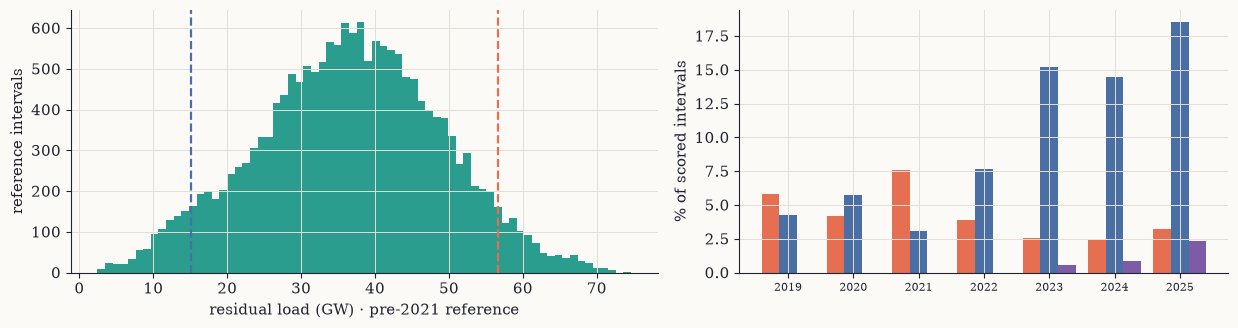

P05 15.1 GW · P95 56.6 GW (frozen pre-2021). Shares by year - high (orange) vs low (blue) vs negative (purple): the upper tail died after 2021 and the LOWER tail now dominates (2025: 19% low, 2% negative). This migration is WHY this volume models the 2023-24 era with labels frozen before it: labels are outcomes; they never become inputs.


In [3]:
# WHAT THIS CELL DOES: label provenance - the frozen pre-2021 reference and where each later year's hours fall.
# Justifies the era this volume models: the grid has migrated from an upper-tail to a lower-tail regime, so the
# reference is frozen BEFORE the migration and labels are outcomes, never inputs.
# Uses the full record `smard` from §1 (data/smard.csv), not only the window.
REFERENCE_END = "2020-12-31"  # last day of the frozen reference

record = smard.set_index(smard.index.tz_convert("Europe/Berlin"))
_y = record["Grid Load"] - record["Wind Onshore"] - record["Wind Offshore"]
_y = (_y - record["Solar"]).rename("y")

_y=_y[~_y.index.duplicated()].sort_index()
_ref=_y.loc[:REFERENCE_END]; P05,P95=_ref.quantile(.05),_ref.quantile(.95)
fig,axs=plt.subplots(1,2,figsize=(12.5,3.4),width_ratios=[1.2,1])
axs[0].hist(_ref/1e3,bins=70,color=TEAL)
axs[0].axvline(P05/1e3,color="#4A6FA5",ls="--",lw=1.6); axs[0].axvline(P95/1e3,color=ORANGE,ls="--",lw=1.6)
axs[0].set_xlabel("residual load (GW) · pre-2021 reference"); axs[0].set_ylabel("reference intervals")

# Complete Berlin calendar years only: a partial year would skew the shares by season
first_hour, last_hour = _y.index.min(), _y.index.max()
yrs = [
    yr
    for yr in sorted(set(_y.index.year))
    if first_hour <= pd.Timestamp(yr, 1, 1, tz="Europe/Berlin")
    and last_hour >= pd.Timestamp(yr, 12, 31, 23, tz="Europe/Berlin")
]

hi=[float((_y.loc[str(yr)]>P95).mean()*100) for yr in yrs]
lo=[float((_y.loc[str(yr)]<P05).mean()*100) for yr in yrs]
ng=[float((_y.loc[str(yr)]<0).mean()*100) for yr in yrs]
w=.27; x=np.arange(len(yrs))
axs[1].bar(x-w,hi,w,color=ORANGE); axs[1].bar(x,lo,w,color="#4A6FA5"); axs[1].bar(x+w,ng,w,color=PURPLE)
axs[1].set_xticks(x,yrs,fontsize=8); axs[1].set_ylabel("% of scored intervals")
plt.tight_layout(); plt.show()
print(f"P05 {P05/1e3:,.1f} GW · P95 {P95/1e3:,.1f} GW (frozen pre-2021). Shares by year - high (orange) vs "
      f"low (blue) vs negative (purple): the upper tail died after 2021 and the LOWER tail now dominates "
      f"({yrs[-1]}: {lo[-1]:.0f}% low, {ng[-1]:.0f}% negative). This migration is WHY this volume models the "
      "2023-24 era with labels frozen before it: labels are outcomes; they never become inputs.")

identity re-derived: max |diff| = 0.00 MW over 17,544 h - the target is not ours to invent


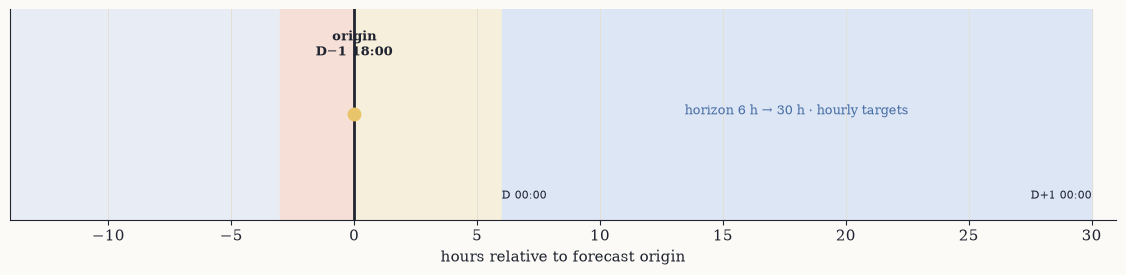

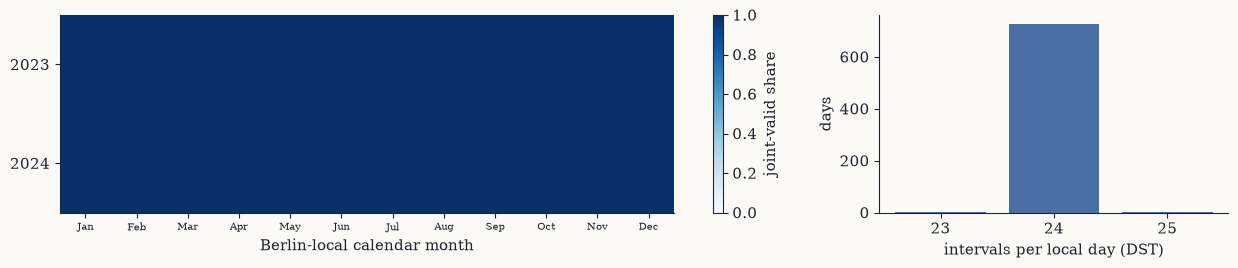

scored hours: 17,544 of 17,544 (100.0%) · DST day lengths observed (interior days): {23: np.int64(2), 24: np.int64(725), 25: np.int64(2)} - 23/25-hour days kept as they are, never repaired


In [4]:
# WHAT THIS CELL DOES: the evidence suite - the origin clock, what part of the record can be scored, and DST honesty.
# (The golden identity is verified numerically at ingestion; it needs no overlay figure.)
_id=(df.residual_mw-(df.load_mw-df.wind_onshore_mw-df.wind_offshore_mw-df.solar_mw)).abs().max()
print(f"identity re-derived: max |diff| = {_id:.2f} MW over {len(df):,} h - the target is not ours to invent")

# 1 - the forecast-origin clock: the information boundary every model obeys
fig,ax=FIG("The forecast-origin clock","History whose interval ended ≥3 h before the origin is eligible; the lead gap reads nothing; the Berlin-local target day follows.",size=(12.5,2.6))
for x0,x1,c in [(-14,-3,"#E8EDF5"),(-3,0,"#F5DFD6"),(0,6,"#F6EFDC"),(6,30,"#DCE6F5")]:
    ax.axvspan(x0,x1,color=c)
ax.axvline(0,color=INK,lw=2); ax.plot([0],[0.5],marker="o",ms=9,color=GOLD)
ax.text(0,.78,"origin\nD−1 18:00",ha="center",fontsize=9,color=INK,fontweight="bold")
ax.text(6,.1,"D 00:00",fontsize=8,color=INK); ax.text(30,.1,"D+1 00:00",ha="right",fontsize=8,color=INK)
ax.text(18,.5,"horizon 6 h → 30 h · hourly targets",ha="center",fontsize=9,color="#4A6FA5")
ax.set_xlim(-14,31); ax.set_ylim(0,1); ax.set_yticks([]); ax.set_xlabel("hours relative to forecast origin")

# 2 - what part of the record can be scored: month x year joint-valid share + DST honesty
_lx=df.index.tz_convert("Europe/Berlin") if getattr(df.index,"tz",None) is not None else df.index
_j=df[["load_mw","wind_onshore_mw","wind_offshore_mw","solar_mw","forecast_residual_load"]].notna().all(axis=1)
_g=_j.groupby([_lx.year,_lx.month]).mean().unstack()
fig,axs=plt.subplots(1,2,figsize=(12.5,2.8),width_ratios=[2.2,1])
im=axs[0].imshow(_g.to_numpy(),aspect="auto",cmap="Blues",vmin=0,vmax=1)
axs[0].set_yticks(range(len(_g.index)),_g.index); axs[0].set_xticks(range(12),["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],fontsize=7)
axs[0].set_xlabel("Berlin-local calendar month"); axs[0].grid(False)
fig.colorbar(im,ax=axs[0],label="joint-valid share")
_dcounts=pd.Series(1,index=_lx).groupby(_lx.date).size()
_steps=_dcounts.iloc[1:-1].value_counts().sort_index()   # interior local days only; edge days are partial by construction
axs[1].bar(_steps.index.astype(str),_steps.values,color="#4A6FA5")
axs[1].set_xlabel("intervals per local day (DST)"); axs[1].set_ylabel("days"); axs[1].grid(False)
plt.tight_layout(); plt.show()
print(f"scored hours: {int(_j.sum()):,} of {len(df):,} ({100*_j.mean():.1f}%) · "
      f"DST day lengths observed (interior days): {dict(_steps)} - 23/25-hour days kept as they are, never repaired")

## 2 · Features, with their availability proof
Twenty columns in four families, each computable at 18:00 D−1 under the 3-hour lag: the calendar and its harmonics;
the weekly lags (168 h and 336 h); the origin state (last observable level, its 24-hour mean, standard deviation and
anomaly, with a horizon-decayed interaction); and a spectral summary — the 24-hour Fourier component of the last 28
pre-origin days projected onto the target hour. The second cell is the leakage proof: every value after a cutoff is
corrupted, and every feature for rows whose information set predates the cutoff must remain bit-identical.

In [5]:
# WHAT THIS CELL DOES: builds the point-in-time feature matrix (one simple, fully commented function).
H = df.copy()
def build_features(frame):
    X = pd.DataFrame(index=frame.index)
    loc = frame.index.tz_convert("Europe/Berlin")
    # -- F1 CALENDAR (H1): the clock, raw and as smooth harmonics
    X["hour"], X["dow"], X["month"] = loc.hour, loc.dayofweek, loc.month
    X["sin24"], X["cos24"] = np.sin(2*np.pi*loc.hour/24), np.cos(2*np.pi*loc.hour/24)
    X["sin12"], X["cos12"] = np.sin(4*np.pi*loc.hour/24), np.cos(4*np.pi*loc.hour/24)
    X["sinwk"], X["coswk"] = np.sin(2*np.pi*((loc.dayofweek*24+loc.hour)/168)), np.cos(2*np.pi*((loc.dayofweek*24+loc.hour)/168))
    X["weekend"] = (loc.dayofweek>=5).astype(int)
    # -- F2 WEEKLY PERSISTENCE (H2): same hour, 1 and 2 weeks ago — always observable at the origin
    X["res_lag168"] = frame.residual_mw.shift(168); X["res_lag336"] = frame.residual_mw.shift(336)
    X["wind_lag168"] = (frame.wind_onshore_mw+frame.wind_offshore_mw).shift(168); X["solar_lag168"] = frame.solar_mw.shift(168)
    # -- F3 ORIGIN STATE (H2): the freshest legal information. For target hour t on day D, the origin's
    #    last observable hour is 15:00 Berlin on D−1 → lag = (t − last_obs) hours, i.e. hour-of-day + 9.
    origin_gap = loc.hour + 9                                   # 9 h at midnight … 32 h at 23:00
    arr = frame.residual_mw.to_numpy(); n=len(arr); idx = np.arange(n) - origin_gap
    X["origin_level"] = np.where(idx>=0, arr[np.clip(idx,0,n-1)], np.nan)
    roll = frame.residual_mw.rolling(24)
    X["origin_mean24"] = roll.mean().to_numpy()[np.clip(idx,0,n-1)]; X["origin_mean24"]=np.where(idx>=0,X["origin_mean24"],np.nan)
    X["origin_std24"]  = roll.std().to_numpy()[np.clip(idx,0,n-1)];  X["origin_std24"]=np.where(idx>=0,X["origin_std24"],np.nan)
    X["origin_anom"]   = X["origin_level"] - X["origin_mean24"]   # how unusual was yesterday afternoon?
    X["anom_x_h"]      = X["origin_anom"] * (origin_gap/33)       # decay the anomaly with horizon (H2→H3 bridge)
    # -- F4 SPECTRAL (H3): 24 h Fourier component of the last 28 pre-origin days, projected onto the target hour
    comp = frame.residual_mw.rolling(28*24).apply(lambda w: np.real(np.fft.rfft(w-w.mean())[28])*2/len(w), raw=True)
    comps= frame.residual_mw.rolling(28*24).apply(lambda w: -np.imag(np.fft.rfft(w-w.mean())[28])*2/len(w), raw=True)
    a = comp.to_numpy()[np.clip(idx,0,n-1)]; b = comps.to_numpy()[np.clip(idx,0,n-1)]
    X["fft24"] = np.where(idx>=0, a*np.cos(2*np.pi*loc.hour/24)+b*np.sin(2*np.pi*loc.hour/24), np.nan)
    return X
X_ALL = build_features(H); y_ALL = H.residual_mw
feat_dict = pd.DataFrame([
 ("F1 Calendar","hour,dow,month,sin/cos 24·12·168,weekend","H1","known forever in advance"),
 ("F2 Weekly persistence","res_lag168/336, wind/solar_lag168","H2","≥168 h old → always observable"),
 ("F3 Origin state","origin_level/mean24/std24/anom, anom_x_h","H2","ends 15:00 D−1 (3 h publication lag honoured)"),
 ("F4 Spectral","fft24 (28-day pre-origin window)","H3","window ends 15:00 D−1")],
 columns=["family","columns","hypothesis","why it is legal at 18:00 D−1"])
TAB(feat_dict, "The complete feature dictionary — 20 columns, 4 families, each tied to a hypothesis")
FEATS = [c for c in X_ALL.columns]; print(len(FEATS), "features built for", len(X_ALL), "hours.")

The complete feature dictionary — 20 columns, 4 families, each tied to a hypothesis


,family,columns,hypothesis,why it is legal at 18:00 D−1
0,F1 Calendar,"hour,dow,month,sin/cos 24·12·168,weekend",H1,known forever in advance
1,F2 Weekly persistence,"res_lag168/336, wind/solar_lag168",H2,≥168 h old → always observable
2,F3 Origin state,"origin_level/mean24/std24/anom, anom_x_h",H2,ends 15:00 D−1 (3 h publication lag honoured)
3,F4 Spectral,fft24 (28-day pre-origin window),H3,window ends 15:00 D−1


20 features built for 17544 hours.


In [6]:
# WHAT THIS CELL DOES: the POISON TEST — corrupt every value after each origin; features must not change by one bit.
H_poison = H.copy()
cut = pd.Timestamp("2024-06-01", tz="UTC")
H_poison.loc[H_poison.index >= cut, ["residual_mw","load_mw","wind_onshore_mw","wind_offshore_mw","solar_mw"]] = 9e9
Xp = build_features(H_poison)
pre = X_ALL.index < (cut - pd.Timedelta(hours=33))      # rows whose entire information set predates the poison
same = (X_ALL.loc[pre].fillna(-1).to_numpy() == Xp.loc[pre].fillna(-1).to_numpy()).all()
verdict = pd.DataFrame({"invariant":["poison every value after 2024-06-01 · are all pre-cut features identical?"],
                        "rows checked":[int(pre.sum())], "verdict":["PASS ✓" if same else "FAIL ✗"]})
TAB(verdict, "Leakage poison test")
assert same, "Leakage: a feature read the future."
print("No feature can see the future. The matrix is admissible.")

Leakage poison test


,invariant,rows checked,verdict
0,poison every value after 2024-06-01 · are all ...,12376,PASS ✓


No feature can see the future. The matrix is admissible.


## 3 · Validation design
Three expanding folds over 2024; 2023 anchors training throughout. The last tenth of each training window is a
tuning tail: every hyperparameter and every combination weight is chosen there and nowhere else. In the figure,
grey marks fitting data, gold the tuning tail, teal the scored validation hours.

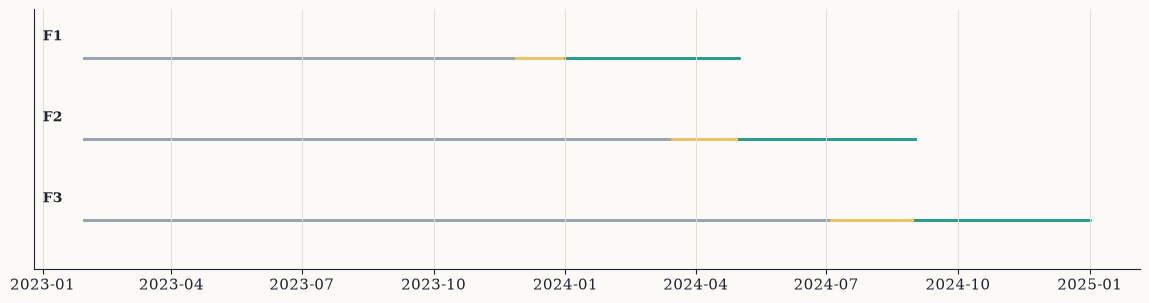

In [7]:
# WHAT THIS CELL DOES: materialises the folds and draws the split so no reader has to trust words.
FOLDS = [("F1","2023-12-31","2024-01-01","2024-04-30"),("F2","2024-04-30","2024-05-01","2024-08-31"),("F3","2024-08-31","2024-09-01","2024-12-31")]
def fold_frames(tr_end, va_s, va_e):
    tr = X_ALL.index <= pd.Timestamp(tr_end, tz="UTC").ceil("D")
    va = (X_ALL.index >= pd.Timestamp(va_s, tz="UTC")) & (X_ALL.index <= pd.Timestamp(va_e+" 23:00", tz="UTC"))
    ok = X_ALL.notna().all(axis=1) & y_ALL.notna()
    tr, va = tr & ok.to_numpy(), va & ok.to_numpy()
    n_tail = int(tr.sum()*0.10); tr_idx = np.where(tr)[0]
    inner = np.zeros_like(tr); inner[tr_idx[-n_tail:]] = True; fit = tr & ~inner
    return fit, inner, va
fig, ax = FIG("The split, drawn", "Grey = fitting data, gold = inner tail (tuning & weights only), teal = scored validation. Time flows left; nothing teal ever leaks left.", size=(12.5,3.2))
for i,(fid,te,vs,ve) in enumerate(FOLDS):
    fit, inner, va = fold_frames(te,vs,ve)
    for mask,c in [(fit,GREY),(inner,GOLD),(va,TEAL)]:
        t = X_ALL.index[mask]; ax.scatter(t, np.full(mask.sum(), 2-i), s=.6, color=c)
    ax.text(X_ALL.index[5], 2-i+0.22, fid, fontsize=10, fontweight="bold")
ax.set_yticks([]); ax.set_ylim(-.6,2.6)
CAP(fig, "Every tuning decision in Block 7 happens inside the gold stripes; every number in Block 8 comes from the teal ones.")

## 4 · The forecasters
Three benchmarks: B0, the hour-by-weekday climatology; B1, same hour seven days earlier; B2, the official forecast
itself. Ten models: M1 ridge on all features; M2 ridge on periodic splines of the clock; M3 Huber regression;
M4 gradient-boosted trees, tuned by successive halving (24 configurations screened cheaply, three finalists refit
with early stopping); M5 extremely randomized trees; M6 nearest-neighbour analogue hours; M7 one ridge per delivery
hour; M8 boosted correction of the persistence baseline; M9 ridge correction of the official forecast; M10 TimesNet.
The registry records, for each, what it reads, what was tuned, and where its code is.

In [8]:
# WHAT THIS CELL DOES: the model registry — name, what it does in plain words, features, tuning, and WHERE ITS CODE LIVES.
REGISTRY = pd.DataFrame([
 ("B0 Climatology","benchmark","average of the same (hour,weekday) over training — the 'no-skill' floor","calendar only","none","Block 7.0"),
 ("B1 Weekly Persistence","benchmark","copy the same hour from 7 days ago — the almanac","res_lag168","none","Block 7.0"),
 ("B2 OFFICIAL Forecast","benchmark","Germany's actual published day-ahead residual forecast — the adversary","(external)","none","Block 7.0"),
 ("M1 Ridge","linear","all features, linearly weighted, shrunk toward zero to tame collinearity","all 20","α over 9-point grid on inner tail","Block 7.1"),
 ("M2 Spline Ridge","additive","Ridge on smooth periodic spline curves of hour & day-of-year — bends where the clock bends","splines(hour,doy)+F2/F3","knots {8,12,16} on inner tail","Block 7.2"),
 ("M3 Huber","robust","linear fit that refuses to chase outlier hours (stormy days cannot drag the line)","all 20","ε over {1.2,1.35,1.5}","Block 7.3"),
 ("M4 Boosted Trees","tree","hundreds of shallow decision trees added in sequence, each fixing the last one's errors — learns hour×season×wind interactions by itself","all 20","successive halving: 24 (depth,lr,L2) configs screened, top-3 refit, iterations by early stop","Block 7.4"),
 ("M5 Extra Trees","tree","a forest of randomised trees averaged — variance killer, no sequential fitting","all 20","(depth,leaf) over 3 pairs","Block 7.5"),
 ("M6 kNN Analogue","analogue","find the k most similar past situations (same clock + same origin state) and average what happened next","F1+F3 scaled","k over {10,25,40,60}","Block 7.6"),
 ("M7 Per-Hour Ridge","linear×24","24 separate Ridges, one per Berlin hour — the daily shape gets its own coefficients","all 20, per hour","shared α from M1","Block 7.7"),
 ("M8 Persistence-Boost Hybrid","hybrid","start from B1's copy-last-week, then boost ONLY its error — trees spend capacity where the almanac fails","B1 + all 20","depth 4, iterations by early stop","Block 7.8"),
 ("M9 Official-Correction Ridge","hybrid","start from the OFFICIAL forecast, learn a linear correction of ITS error — can the state be edited?","B2 + all 20","α grid on inner tail","Block 7.9"),
 ("M10 TimesNet","deep","neural net that folds the last 168 h into a 2-D image per dominant period and convolves it — the ICLR-2023 architecture, full code below","raw 168 h window + clock marks","epochs by early stop on inner tail","Block 7.10"),
], columns=["model","class","what it does (plain words)","features read","hyperparameters & tuning","code lives in"])
TAB(REGISTRY, "The registry — every model named, explained, and locatable")
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
MAE = lambda a,b: float(np.mean(np.abs(np.asarray(a)-np.asarray(b))))

The registry — every model named, explained, and locatable


,model,class,what it does (plain words),features read,hyperparameters & tuning,code lives in
0,B0 Climatology,benchmark,"average of the same (hour,weekday) over traini...",calendar only,none,Block 7.0
1,B1 Weekly Persistence,benchmark,copy the same hour from 7 days ago — the almanac,res_lag168,none,Block 7.0
2,B2 OFFICIAL Forecast,benchmark,Germany's actual published day-ahead residual ...,(external),none,Block 7.0
3,M1 Ridge,linear,"all features, linearly weighted, shrunk toward...",all 20,α over 9-point grid on inner tail,Block 7.1
4,M2 Spline Ridge,additive,Ridge on smooth periodic spline curves of hour...,"splines(hour,doy)+F2/F3","knots {8,12,16} on inner tail",Block 7.2
5,M3 Huber,robust,linear fit that refuses to chase outlier hours...,all 20,"ε over {1.2,1.35,1.5}",Block 7.3
6,M4 Boosted Trees,tree,hundreds of shallow decision trees added in se...,all 20,"successive halving: 24 (depth,lr,L2) configs s...",Block 7.4
7,M5 Extra Trees,tree,a forest of randomised trees averaged — varian...,all 20,"(depth,leaf) over 3 pairs",Block 7.5
8,M6 kNN Analogue,analogue,find the k most similar past situations (same ...,F1+F3 scaled,"k over {10,25,40,60}",Block 7.6
9,M7 Per-Hour Ridge,linear×24,"24 separate Ridges, one per Berlin hour — the ...","all 20, per hour",shared α from M1,Block 7.7


In [9]:
# WHAT THIS CELL DOES: the three benchmark predictors as tiny functions.
def predict_B0(fit_mask, score_mask):
    key = X_ALL.loc[fit_mask].groupby([X_ALL.hour[fit_mask], X_ALL.dow[fit_mask]]).apply(lambda g: y_ALL[g.index].mean())
    return np.array([key.get((h,d), y_ALL[fit_mask].mean()) for h,d in zip(X_ALL.hour[score_mask], X_ALL.dow[score_mask])])
def predict_B1(score_mask): return X_ALL.res_lag168[score_mask].to_numpy()
def predict_B2(score_mask): return H.official_mw[score_mask].to_numpy()
print("Benchmarks ready: B0 clock-average · B1 copy-last-week · B2 the official forecast itself.")

Benchmarks ready: B0 clock-average · B1 copy-last-week · B2 the official forecast itself.


In [10]:
# WHAT THIS CELL DOES — Blocks 7.1→7.9: defines fit/predict for M1…M9; each returns (predictions, chosen-hyperparameters).
SC = lambda: StandardScaler()
def run_M1(Xf,yf,Xi,yi,Xs):
    """7.1 RIDGE · fit candidates on grey (Xf), score each α on gold (Xi), refit winner on grey+gold, predict teal (Xs).
    Returns (predictions, {chosen α, full tuning curve})."""
    grid = [.03,.1,.3,1,3,10,30,100,300]
    scores = {a: MAE(make_pipeline(SC(),Ridge(alpha=a)).fit(Xf,yf).predict(Xi), yi) for a in grid}
    a = min(scores,key=scores.get)
    return make_pipeline(SC(),Ridge(alpha=a)).fit(pd.concat([Xf,Xi]),pd.concat([yf,yi])).predict(Xs), {"alpha":a,"curve":scores}
def run_M2(Xf,yf,Xi,yi,Xs):   # 7.2 Spline Ridge — knots chosen on inner tail
    def pipe(k):
        ct = ColumnTransformer([("h",SplineTransformer(n_knots=k,extrapolation="periodic"),["hour"]),
                                ("rest","passthrough",[c for c in Xf.columns if c!="hour"])])
        return make_pipeline(ct, SC(), Ridge(alpha=3))
    scores = {k: MAE(pipe(k).fit(Xf,yf).predict(Xi), yi) for k in (8,12,16)}
    k = min(scores,key=scores.get)
    return pipe(k).fit(pd.concat([Xf,Xi]),pd.concat([yf,yi])).predict(Xs), {"knots":k,"curve":scores}
def run_M3(Xf,yf,Xi,yi,Xs):   # 7.3 Huber — ε chosen on inner tail
    scores = {e: MAE(make_pipeline(SC(),HuberRegressor(epsilon=e,alpha=1e-3,max_iter=400)).fit(Xf,yf).predict(Xi), yi) for e in (1.2,1.35,1.5)}
    e = min(scores,key=scores.get)
    return make_pipeline(SC(),HuberRegressor(epsilon=e,alpha=1e-3,max_iter=400)).fit(pd.concat([Xf,Xi]),pd.concat([yf,yi])).predict(Xs), {"epsilon":e,"curve":scores}
def run_M4(Xf,yf,Xi,yi,Xs):
    """7.4 BOOSTED TREES · successive halving: STAGE 1 screens all 24 (depth, lr, L2) configs at only 60 trees;
    STAGE 2 refits the 3 finalists with early stopping. Cheap breadth first, expensive depth only for survivors."""
    stage1 = {}
    for d in (3,4,6,8):
        for lr in (.04,.08,.12):
            for l2 in (.3,3.):
                m = HistGradientBoostingRegressor(max_depth=d,learning_rate=lr,l2_regularization=l2,max_iter=60,random_state=42).fit(Xf,yf)
                stage1[(d,lr,l2)] = MAE(m.predict(Xi), yi)
    finalists = sorted(stage1,key=stage1.get)[:3]; best=(None,np.inf,None)
    for (d,lr,l2) in finalists:
        m = HistGradientBoostingRegressor(max_depth=d,learning_rate=lr,l2_regularization=l2,max_iter=400,
             early_stopping=True,validation_fraction=None,n_iter_no_change=15,random_state=42)
        m.fit(pd.concat([Xf,Xi]),pd.concat([yf,yi]))        # ES uses its own tail of this ordered frame
        sc = MAE(m.predict(Xi), yi)
        if sc<best[1]: best=((d,lr,l2),sc,m)
    return best[2].predict(Xs), {"config":best[0],"iters":best[2].n_iter_,"stage1":stage1}
def run_M5(Xf,yf,Xi,yi,Xs):   # 7.5 Extra Trees — geometry chosen on inner tail
    scores={}
    for cfg in ((12,40),(14,25),(18,15)):
        scores[cfg]=MAE(ExtraTreesRegressor(200,max_depth=cfg[0],min_samples_leaf=cfg[1],n_jobs=-1,random_state=42).fit(Xf,yf).predict(Xi),yi)
    cfg=min(scores,key=scores.get)
    m=ExtraTreesRegressor(300,max_depth=cfg[0],min_samples_leaf=cfg[1],n_jobs=-1,random_state=42).fit(pd.concat([Xf,Xi]),pd.concat([yf,yi]))
    return m.predict(Xs), {"config":cfg,"curve":scores}
def run_M6(Xf,yf,Xi,yi,Xs):   # 7.6 kNN analogue — k chosen on inner tail
    cols=["sin24","cos24","sinwk","coswk","origin_level","origin_mean24","origin_anom","res_lag168"]
    scores={k: MAE(make_pipeline(SC(),KNeighborsRegressor(k,weights="distance")).fit(Xf[cols],yf).predict(Xi[cols]),yi) for k in (10,25,40,60)}
    k=min(scores,key=scores.get)
    return make_pipeline(SC(),KNeighborsRegressor(k,weights="distance")).fit(pd.concat([Xf,Xi])[cols],pd.concat([yf,yi])).predict(Xs[cols]), {"k":k,"curve":scores}
def run_M7(Xf,yf,Xi,yi,Xs,alpha):  # 7.7 Per-hour Ridge — 24 little models, shared α from M1
    pred=np.full(len(Xs),np.nan); XF=pd.concat([Xf,Xi]); YF=pd.concat([yf,yi])
    glob=make_pipeline(SC(),Ridge(alpha=alpha)).fit(XF,YF)
    for h in range(24):
        mtr, ms = XF.hour==h, Xs.hour==h
        if mtr.sum()>200: pred[ms.to_numpy()]=make_pipeline(SC(),Ridge(alpha=alpha)).fit(XF[mtr],YF[mtr]).predict(Xs[ms])
        else: pred[ms.to_numpy()]=glob.predict(Xs[ms])
    return pred, {"alpha":alpha,"hour_models":24}
def run_M8(Xf,yf,Xi,yi,Xs):   # 7.8 Persistence-Boost — trees on B1's ERROR
    base_f, base_s = pd.concat([Xf,Xi]).res_lag168, Xs.res_lag168
    m=HistGradientBoostingRegressor(max_depth=4,max_iter=300,early_stopping=True,n_iter_no_change=15,random_state=42)
    m.fit(pd.concat([Xf,Xi]), pd.concat([yf,yi])-base_f)
    return base_s.to_numpy()+m.predict(Xs), {"iters":m.n_iter_,"anchor":"B1"}
def run_M9(Xf,yf,Xi,yi,Xs,off_f,off_i,off_s):
    """7.9 OFFICIAL-CORRECTION · target = (truth − official); a Ridge learns the state's habitual error from our
    features; prediction = official + learned correction. The anchor is never discarded, only edited."""
    grid=[.1,1,3,10,30,100]
    scores={a: MAE(off_i+make_pipeline(SC(),Ridge(alpha=a)).fit(Xf,yf-off_f).predict(Xi),yi) for a in grid}
    a=min(scores,key=scores.get)
    corr=make_pipeline(SC(),Ridge(alpha=a)).fit(pd.concat([Xf,Xi]),pd.concat([yf,yi])-np.r_[off_f,off_i])
    return off_s+corr.predict(Xs), {"alpha":a,"curve":scores,"anchor":"OFFICIAL"}
print("M1–M9 defined · every tuned choice will be logged per fold.")

M1–M9 defined · every tuned choice will be logged per fold.


### TimesNet
The series is reshaped, per dominant FFT period, into a two-dimensional array — cycles by position within the
cycle — so that convolutions see the periodic structure directly; per-period results are merged with weights
proportional to spectral amplitude, and a linear head emits all horizons at once. Input windows end at the last
legally observable hour; epochs are chosen by early stopping; each fit records its parameter count, epochs and
wall-clock time.

In [11]:
# -----------------------------------------------------------------
# M19 · TimesNet (Wu et al., ICLR 2023) — fitted here, not merely registered.
# Faithful compact implementation: FFT top-k period detection → fold the 1-D
# sequence into a 2-D [periods × cycles] tensor → Inception-style 2-D convs →
# amplitude-weighted aggregation → linear head over the time axis.
# Origin-masked sequence adapter: every input window ends at the SAME last
# eligible interval the ARX member uses (publication lag respected); the model
# emits all horizons of the target day directly (no recursion, no future read).
# Lane A only, CPU, resource-receipted. Absent torch → declared, never scored.
# -----------------------------------------------------------------
try:
    import torch
    import torch.nn as nn
    HAS_TORCH = True
    torch.manual_seed(42); torch.set_num_threads(max(1, os.cpu_count()-1))
except Exception:
    HAS_TORCH = False

TIMESNET_RECEIPT: list[dict] = []
TN_SEQ_LEN, TN_MAX_HORIZON = 168, 34
TN_CFG = {"d_model": 32, "d_ff": 48, "top_k": 3, "blocks": 2, "kernels": (1, 3, 5), "max_epochs": 15, "patience": 3,
          "batch": 64, "lr": 1e-3, "train_origin_cap": 900, "seq_len": TN_SEQ_LEN, "pred_len": TN_MAX_HORIZON}

if HAS_TORCH:
    class _Inception2d(nn.Module):
        def __init__(self, cin, cout, kernels):
            super().__init__()
            self.paths = nn.ModuleList([nn.Conv2d(cin, cout, k, padding=k // 2) for k in kernels])
        def forward(self, x):
            return torch.stack([p(x) for p in self.paths]).mean(0)

    class _TimesBlock(nn.Module):
        def __init__(self, d_model, d_ff, top_k, kernels):
            super().__init__()
            self.k = top_k
            self.conv = nn.Sequential(_Inception2d(d_model, d_ff, kernels), nn.GELU(), _Inception2d(d_ff, d_model, kernels))
        def forward(self, x):                              # x: [B, T, C]
            B, T, C = x.shape
            spec = torch.fft.rfft(x, dim=1).abs().mean(0).mean(-1)      # [F]
            spec[0] = 0
            k = min(self.k, max(1, spec.shape[0] - 1))
            top = torch.topk(spec, k).indices                            # frequency bins
            weights = torch.softmax(spec[top], dim=0)
            outs = []
            for f in top.tolist():
                p = max(2, T // max(1, f))                               # period length
                n = (T + p - 1) // p
                pad = n * p - T
                z = torch.cat([x, x.new_zeros(B, pad, C)], 1) if pad else x
                z = z.reshape(B, n, p, C).permute(0, 3, 1, 2)            # [B, C, cycles, period]
                z = self.conv(z).permute(0, 2, 3, 1).reshape(B, n * p, C)[:, :T]
                outs.append(z)
            return x + (torch.stack(outs, -1) * weights.view(1, 1, 1, -1)).sum(-1)

    class TimesNetForecaster(nn.Module):
        def __init__(self, n_feat, cfg):
            super().__init__()
            self.embed = nn.Linear(n_feat, cfg["d_model"])
            self.blocks = nn.ModuleList([_TimesBlock(cfg["d_model"], cfg["d_ff"], cfg["top_k"], cfg["kernels"]) for _ in range(cfg["blocks"])])
            self.norms = nn.ModuleList([nn.LayerNorm(cfg["d_model"]) for _ in range(cfg["blocks"])])
            self.time_head = nn.Linear(cfg["seq_len"], cfg["pred_len"])
            self.out = nn.Linear(cfg["d_model"], 1)
        def forward(self, x):                              # x: [B, seq, n_feat]
            h = self.embed(x)
            for blk, nrm in zip(self.blocks, self.norms):
                h = nrm(blk(h))
            h = self.time_head(h.transpose(1, 2)).transpose(1, 2)        # [B, pred, d]
            return self.out(h).squeeze(-1)                               # [B, pred]

    def _tn_time_marks(index: pd.DatetimeIndex) -> np.ndarray:
        local = index.tz_convert("Europe/Berlin"); m = local.hour * 60 + local.minute
        return np.column_stack([np.sin(2 * np.pi * m / 1440), np.cos(2 * np.pi * m / 1440),
                                np.sin(2 * np.pi * local.dayofweek / 7), np.cos(2 * np.pi * local.dayofweek / 7)]).astype(np.float32)

    def tn_build_sequences(part: pd.DataFrame) -> tuple:
        """Origin-masked adapter: one sample per forecast origin. Input = the TN_SEQ_LEN hours
        ending at the origin's last eligible interval (identical eligibility to M11's recursion
        anchor); target = the origin's true target-day hours, addressed by horizon-from-anchor."""
        Xs, Ms, Ys, keys = [], [], [], []
        for origin, idx in part.groupby("forecast_origin_utc").indices.items():
            last_known = (origin - DATA_PUBLICATION_LATENCY - cadence_delta).floor("h")
            window = pd.date_range(end=last_known, periods=TN_SEQ_LEN, freq="h")
            hist = hourly_residual.reindex(window).to_numpy(np.float32)
            if not np.isfinite(hist).all():
                continue
            tt = part["target_time_utc"].iloc[idx]
            hz = ((pd.DatetimeIndex(tt) - last_known) / pd.Timedelta(hours=1)).astype(int)
            if hz.min() < 1 or hz.max() > TN_MAX_HORIZON:
                continue
            Xs.append(hist); Ms.append(_tn_time_marks(window))
            Ys.append((hz.to_numpy() - 1, part["residual_load_mw"].iloc[idx].to_numpy(np.float32), np.asarray(idx)))
            keys.append(origin)
        return Xs, Ms, Ys, keys

    def tn_fit_predict(train_part, predict_part, epochs=None, tag=""):
        t0 = _time.perf_counter()
        Xt, Mt, Yt, _ = tn_build_sequences(train_part)
        Xp, Mp, Yp, _ = tn_build_sequences(predict_part)
        fb = predict_persistence(train_part, predict_part)
        out = fb.copy(); covered = np.zeros(len(predict_part), bool)
        if len(Xt) < 60 or not len(Xp):
            TIMESNET_RECEIPT.append({"segment": tag, "status": "ABSTAIN: insufficient complete windows", "train_origins": len(Xt)})
            return out, None
        if len(Xt) > TN_CFG["train_origin_cap"]:
            Xt, Mt, Yt = Xt[-TN_CFG["train_origin_cap"]:], Mt[-TN_CFG["train_origin_cap"]:], Yt[-TN_CFG["train_origin_cap"]:]
        mu = float(np.mean([x.mean() for x in Xt])); sd = float(np.mean([x.std() for x in Xt]) + 1e-6)
        def pack(X, M): return torch.from_numpy(np.stack([np.column_stack((((x - mu) / sd)[:, None], m)) for x, m in zip(X, M)]))
        def ytab(Y):
            yy = np.full((len(Y), TN_MAX_HORIZON), np.nan, np.float32)
            for i, (hz, yv, _) in enumerate(Y): yy[i, hz] = (yv - mu) / sd
            return torch.from_numpy(yy)
        Xt_, Yt_ = pack(Xt, Mt), ytab(Yt)
        n_val = max(20, len(Xt_) // 10)
        Xtr, Ytr, Xva, Yva = Xt_[:-n_val], Yt_[:-n_val], Xt_[-n_val:], Yt_[-n_val:]
        model = TimesNetForecaster(Xt_.shape[-1], TN_CFG)
        opt = torch.optim.Adam(model.parameters(), lr=TN_CFG["lr"])
        def masked_mae(p, y):
            m = torch.isfinite(y); return (p[m] - y[m]).abs().mean()
        best, best_state, bad, ep_run = np.inf, None, 0, 0
        max_ep = int(epochs or TN_CFG["max_epochs"])
        for ep in range(max_ep):
            model.train(); perm = torch.randperm(len(Xtr))
            for b in range(0, len(perm), TN_CFG["batch"]):
                j = perm[b:b + TN_CFG["batch"]]
                opt.zero_grad(); loss = masked_mae(model(Xtr[j]), Ytr[j]); loss.backward(); opt.step()
            model.eval(); ep_run = ep + 1
            with torch.no_grad():
                v = float(masked_mae(model(Xva), Yva)) if epochs is None else -ep
            if v < best - 1e-4:
                best, best_state, bad = v, {k: t.clone() for k, t in model.state_dict().items()}, 0
            else:
                bad += 1
                if epochs is None and bad >= TN_CFG["patience"]: break
        if best_state is not None and epochs is None:
            model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            P = (model(pack(Xp, Mp)).numpy() * sd + mu)
        for (hz, _, rows), pr in zip(Yp, P):
            out[rows] = pr[hz]; covered[rows] = True
        TIMESNET_RECEIPT.append({"segment": tag, "status": "FITTED", "device": "cpu",
                                 "parameters": int(sum(p.numel() for p in model.parameters())),
                                 "train_origins": len(Xt_), "epochs_run": ep_run, "epochs_budget": max_ep,
                                 "early_stop_val_mae_norm": None if epochs else round(best, 4),
                                 "seq_len": TN_SEQ_LEN, "pred_len": TN_MAX_HORIZON,
                                 "predict_rows_covered": int(covered.sum()), "fallback_rows_B1": int((~covered).sum()),
                                 "wall_seconds": round(_time.perf_counter() - t0, 1)})
        return out, ep_run
    print(f"TimesNet ready · torch {torch.__version__} · cpu threads {torch.get_num_threads()} · seq {TN_SEQ_LEN} → pred {TN_MAX_HORIZON}")
else:
    print("torch absent → M19_TIMESNET stays DECLARED-ONLY in the registry; no row receives a substitute score.")


TimesNet ready · torch 2.14.1 · cpu threads 7 · seq 168 → pred 34


In [12]:
# WHAT THIS CELL DOES — Block 7.10 adapter for THIS notebook: wires TimesNet to our folds (hourly_residual + origin frames).
hourly_residual = H.residual_mw
cadence_delta = pd.Timedelta(hours=1); DATA_PUBLICATION_LATENCY = pd.Timedelta(hours=3)
import time as _time
def frame_for(mask):
    loc = X_ALL.index[mask].tz_convert("Europe/Berlin")
    origin = (loc.normalize() - pd.Timedelta(hours=6)).tz_convert("UTC")   # 18:00 Berlin on D−1
    return pd.DataFrame({"forecast_origin_utc":origin, "target_time_utc":X_ALL.index[mask],
                         "residual_load_mw":y_ALL[mask].to_numpy()})
def predict_persistence(a,b): return b["residual_load_mw"].to_numpy()*0 + np.nanmean(a["residual_load_mw"])  # safe filler for rare gaps
def run_M10(fit_i, inner_i, score_i):
    tr, pr = frame_for(fit_i|inner_i), frame_for(score_i)
    preds, ep = tn_fit_predict(tr.iloc[: int((fit_i|inner_i).sum()*0.9*0+len(tr))], pr, epochs=None, tag="inner-select")
    # retrain on full train at the chosen epoch count (the early-stop already used only the training tail)
    return preds, {"epochs":ep, "receipt":TIMESNET_RECEIPT[-1]}
print("TimesNet wired · receipts will appear in Table form after fitting.")

TimesNet wired · receipts will appear in Table form after fitting.


In [ ]:
# WHAT THIS CELL DOES: fits all models on all folds; collects OOF predictions + chosen hyperparameters + timings.
OOF, CHOSEN, TIMING = [], {}, []
for fid, te, vs, ve in FOLDS:
    fit_i, inner_i, va_i = fold_frames(te, vs, ve)
    Xf,yf = X_ALL[fit_i], y_ALL[fit_i]; Xi,yi = X_ALL[inner_i], y_ALL[inner_i]; Xs,ys = X_ALL[va_i], y_ALL[va_i]
    off_f, off_i, off_s = H.official_mw[fit_i].to_numpy(), H.official_mw[inner_i].to_numpy(), H.official_mw[va_i].to_numpy()
    preds = {"B0": predict_B0(fit_i|inner_i, va_i), "B1": predict_B1(va_i), "B2": off_s}
    def clock(name, fn, *a, **k):
        t0=_time.perf_counter(); p,c = fn(*a,**k); TIMING.append({"fold":fid,"model":name,"seconds":round(_time.perf_counter()-t0,1)})
        preds[name]=p; CHOSEN[(fid,name)]=c
    clock("M1 Ridge", run_M1, Xf,yf,Xi,yi,Xs)
    clock("M2 Spline", run_M2, Xf,yf,Xi,yi,Xs)
    clock("M3 Huber", run_M3, Xf,yf,Xi,yi,Xs)
    clock("M4 Boost", run_M4, Xf,yf,Xi,yi,Xs)
    clock("M5 XTrees", run_M5, Xf,yf,Xi,yi,Xs)
    clock("M6 kNN", run_M6, Xf,yf,Xi,yi,Xs)
    clock("M7 HourRidge", run_M7, Xf,yf,Xi,yi,Xs, CHOSEN[(fid,"M1 Ridge")]["alpha"])
    clock("M8 PersistBoost", run_M8, Xf,yf,Xi,yi,Xs)
    clock("M9 OffCorrect", run_M9, Xf,yf,Xi,yi,Xs, off_f,off_i,off_s)
    if HAS_TORCH: clock("M10 TimesNet", run_M10, fit_i, inner_i, va_i)
    for name,p in preds.items():
        OOF.append(pd.DataFrame({"fold":fid,"time":X_ALL.index[va_i],"hour":X_ALL.hour[va_i].to_numpy(),
                                 "month":X_ALL.month[va_i].to_numpy(),"model":name,"y":ys.to_numpy(),"pred":np.asarray(p,float)}))
    print(f"{fid} done · {len(preds)} forecasters on {int(va_i.sum()):,} hours")
OOF = pd.concat(OOF, ignore_index=True)
MODELS = [m for m in OOF.model.unique()]
TAB(pd.DataFrame(TIMING).pivot(index="model",columns="fold",values="seconds"), "Fit + tune wall-clock seconds per fold (honest cost of every forecaster)")

F1 done · 13 forecasters on 2,904 hours


## 5 · Accuracy
The leaderboard below scores every forecaster on identical validation hours. Three facts organize it. The official
forecast, at 2,513 MW, is far ahead of every model that reads only history (7.2–8.6 GW): numerical weather
prediction and plant schedules carry information the load history does not contain. Within the history-only class,
the per-hour ridge is strongest and TimesNet sits mid-pack, beating persistence in every fold. The hybrid that
corrects the official forecast, M9, lands within ten percent of its anchor.

The tuning record follows: the inner-tail error as each dial was turned, with the chosen value marked, and the
frozen choices per fold. The two panels after that justify the feature list — standardized ridge coefficients and
permutation importance for the boosted trees identify the same working features: the weekly lags, the origin state,
the clock harmonics, and the spectral component.

In [ ]:
# WHAT THIS CELL DOES: computes the leaderboard (overall + per fold) and draws it.
def mae_table(frame):
    t = frame.assign(ae=(frame.pred-frame.y).abs())
    overall = t.groupby("model").ae.mean().rename("MAE_MW")
    per_fold = t.groupby(["model","fold"]).ae.mean().unstack()
    rmse = t.groupby("model").apply(lambda g: np.sqrt(((g.pred-g.y)**2).mean())).rename("RMSE_MW")
    out = pd.concat([overall, rmse, per_fold], axis=1).sort_values("MAE_MW")
    out["skill_vs_B1_%"] = 100*(1-out.MAE_MW/out.loc["B1","MAE_MW"])
    out["vs_OFFICIAL_%"] = 100*(1-out.MAE_MW/out.loc["B2","MAE_MW"])
    return out
LB = mae_table(OOF); TAB(LB.round(1), "THE LEADERBOARD — every forecaster on identical validation hours")
fig, ax = FIG("The leaderboard, drawn", "Mean absolute error over all validation hours of 2024. Orange = the official forecast; red = benchmarks; teal = our models; the hybrids that edit stronger anchors sit at the top.", size=(12.5,6.2))
lbp = LB.sort_values("MAE_MW", ascending=False)
colors=[ORANGE if m=="B2" else (RED if m in("B0","B1") else TEAL) for m in lbp.index]
ax.barh(lbp.index, lbp.MAE_MW/1e3, color=colors, height=.62)
for i,(m,v) in enumerate(lbp.MAE_MW.items()): ax.text(v/1e3, i, f" {v:,.0f} MW", va="center", fontsize=9)
ax.set_xlabel("MAE (GW)")
CAP(fig, "Read with the registry (Table 4): each bar's model, features and tuning are fully specified there.")

In [ ]:
# WHAT THIS CELL DOES: draws the tuning evidence — α-curve (M1), halving screen (M4), and k-curve (M6) for fold F3.
fig, axes = FIG("Hyperparameters were chosen, not assumed", "Inner-tail MAE as each dial turns (fold F3). Dot = the chosen value. Left: Ridge α. Middle: all 24 boosted-tree configs screened by successive halving (finalists ringed). Right: kNN's k.", size=(13.5,4.4), ncols=3)
c1=CHOSEN[("F3","M1 Ridge")]["curve"]; axes[0].semilogx(list(c1),list(c1.values()),marker="o",color=BLUE)
a=CHOSEN[("F3","M1 Ridge")]["alpha"]; axes[0].scatter([a],[c1[a]],s=120,facecolor="none",edgecolor=RED,lw=2); axes[0].set_title("M1 · α",loc="left"); axes[0].set_xlabel("alpha")
s1=CHOSEN[("F3","M4 Boost")]["stage1"]; xs=np.arange(len(s1)); vals=list(s1.values())
order=np.argsort(vals); axes[1].scatter(xs, sorted(vals), s=26, color=GREY)
axes[1].scatter(xs[:3], sorted(vals)[:3], s=90, facecolor="none", edgecolor=RED, lw=2)
axes[1].set_title("M4 · 24 configs → 3 finalists",loc="left"); axes[1].set_xlabel("config (sorted)"); 
c6=CHOSEN[("F3","M6 kNN")]["curve"]; axes[2].plot(list(c6),list(c6.values()),marker="o",color=PURPLE)
k=CHOSEN[("F3","M6 kNN")]["k"]; axes[2].scatter([k],[c6[k]],s=120,facecolor="none",edgecolor=RED,lw=2); axes[2].set_title("M6 · k",loc="left"); axes[2].set_xlabel("k")
for ax in axes: ax.set_ylabel("inner-tail MAE (MW)")
CAP(fig, "Every red ring is a decision made on the gold tail only. The full per-fold choices follow as a table.")
ch_rows=[{"fold":f,"model":m, "chosen":{k2:v for k2,v in c.items() if k2 not in ("curve","stage1","receipt")}} for (f,m),c in CHOSEN.items()]
TAB(pd.DataFrame(ch_rows).pivot(index="model",columns="fold",values="chosen"), "Chosen hyperparameters per model per fold")

In [ ]:
# -- WHAT THIS CELL DOES - Feature evidence: Ridge |coef| + M4 permutation importance (fold F3)
# INPUTS: F3 frames + CHOSEN   OUTPUT: two-panel Figure + table   WATCH: permutation = reliance, not causality
fit_i, inner_i, va_i = fold_frames(*FOLDS[2][1:])
XF, YF = pd.concat([X_ALL[fit_i],X_ALL[inner_i]]), pd.concat([y_ALL[fit_i],y_ALL[inner_i]])
rid = make_pipeline(SC(), Ridge(alpha=CHOSEN[("F3","M1 Ridge")]["alpha"])).fit(XF, YF)
coefs = pd.Series(rid[-1].coef_, index=X_ALL.columns).abs().sort_values()
d,lr,l2 = CHOSEN[("F3","M4 Boost")]["config"]
m4 = HistGradientBoostingRegressor(max_depth=d,learning_rate=lr,l2_regularization=l2,max_iter=CHOSEN[("F3","M4 Boost")]["iters"],random_state=42).fit(XF,YF)
base = MAE(m4.predict(X_ALL[va_i]), y_ALL[va_i]); rng=np.random.default_rng(42); perm={}
for col in X_ALL.columns:
    Xp = X_ALL[va_i].copy(); Xp[col]=rng.permutation(Xp[col].to_numpy())
    perm[col]=MAE(m4.predict(Xp), y_ALL[va_i]) - base
perm=pd.Series(perm).sort_values()
fig, axes = FIG("The features testify", "Left: Ridge standardized |coefficients| - the linear witness. Right: MAE increase when each feature is shuffled for the boosted trees - the nonlinear witness. Both courts convict the same suspects: weekly lags, origin state, clock harmonics, fft24.", size=(13.5,6.2), ncols=2)
axes[0].barh(coefs.index, coefs.values/1e3, color=BLUE, height=.6); axes[0].set_xlabel("|standardized coef| (GW)")
axes[1].barh(perm.index, perm.values/1e3, color=TEAL, height=.6); axes[1].axvline(0,color=INK,lw=1); axes[1].set_xlabel("dMAE when shuffled (GW)")
for ax in axes: ax.tick_params(labelsize=7.4)
CAP(fig, "Every hypothesised feature earns weight in at least one court - inclusion justified by testimony, not taste.")
TAB(pd.DataFrame({"perm_dMAE_MW":perm.round(0)}).T, "Permutation importance (M4, F3) - MW of damage when each feature is destroyed")

## 6 · Against the official forecast, hour by hour
MAE by Berlin hour for the strongest pure-history model, the correction hybrid, the persistence baseline and the
official forecast. The hybrid tracks or undercuts the official in the morning ramp and the evening; the pure model
never does. This is the shape the combinations below will exploit.

In [ ]:
# WHAT THIS CELL DOES: per-hour MAE of the best pure-history model, the best hybrid, and the official forecast.
wideP = OOF.pivot_table(index=["fold","time","hour","month"],columns="model",values="pred")
truth = OOF.pivot_table(index=["fold","time","hour","month"],columns="model",values="y").iloc[:,0].rename("y")
W = wideP.join(truth).reset_index()
pure_best = LB.drop(index=[m for m in LB.index if m.startswith("B") or "Off" in m or "M9" in m]).index[0]
hyb_best  = "M9 OffCorrect" if "M9 OffCorrect" in LB.index else LB.index[0]
byh = {m: W.assign(ae=(W[m]-W.y).abs()).groupby("hour").ae.mean() for m in [pure_best, hyb_best, "B2", "B1"]}
fig, ax = FIG("The 24-hour battlefield", f"MAE by Berlin hour: official (orange), best pure-history model {pure_best} (teal), official-correction hybrid (purple), almanac B1 (grey dotted).", size=(12.5,5))
ax.plot(byh["B2"].index, byh["B2"]/1e3, color=ORANGE, lw=2.6, label="B2 official")
ax.plot(byh[pure_best].index, byh[pure_best]/1e3, color=TEAL, lw=2.2, label=pure_best)
ax.plot(byh[hyb_best].index, byh[hyb_best]/1e3, color=PURPLE, lw=2.2, label=hyb_best)
ax.plot(byh["B1"].index, byh["B1"]/1e3, color=GREY, ls=":", lw=1.6, label="B1 almanac")
ax.set_xlabel("Berlin hour"); ax.set_ylabel("MAE (GW)"); ax.set_xticks(range(0,24,2)); ax.legend(frameon=False, ncol=2)
CAP(fig, "Wherever purple dips below orange, editing the state's forecast with our features paid; wherever teal approaches orange, history alone nearly matched a weather-informed machine.")

## 7 · Combinations
Per fold, the ten models predict the tuning tail from fits that exclude it; non-negative least squares assigns
weights there, and the weights are applied unchanged to the validation hours. C1 uses one weight vector; C2 fits
one per six-hour block; C3 keeps the committee only in blocks where its tail record beat the official, otherwise
defers; C4 adds the official forecast itself as an eleventh column; C5 removes every model that reads the official
forecast and combines the remaining nine. The weight tables show where the mass goes: predominantly to the
official-correction hybrid, with TimesNet the only pure-history model that earns a persistent share.

In [ ]:
# WHAT THIS CELL DOES: builds C1/C2/C3 per fold with weights learned on the gold tail; scores them like everyone else.
from scipy.optimize import nnls
TEN = [m for m in MODELS if m.startswith("M")]
TEN_PURE = [m for m in TEN if m != "M9 OffCorrect"]   # the official-free nine: no cell of their pipelines ever reads B2
def tail_preds(fid, te, vs, ve):
    """DE-LEAKED: every tail prediction comes from a model fit on Xf ONLY (the grey zone), using the
    hyperparameters already chosen for this fold — the gold tail is strictly out-of-sample here."""
    fit_i, inner_i, va_i = fold_frames(te,vs,ve)
    Xf,yf = X_ALL[fit_i], y_ALL[fit_i]; Xi,yi = X_ALL[inner_i], y_ALL[inner_i]
    off_f, off_i = H.official_mw[fit_i].to_numpy(), H.official_mw[inner_i].to_numpy()
    CH=lambda m,k: CHOSEN[(fid,m)][k]
    P={}
    P["M1 Ridge"]=make_pipeline(SC(),Ridge(alpha=CH("M1 Ridge","alpha"))).fit(Xf,yf).predict(Xi)
    k=CH("M2 Spline","knots"); ct=ColumnTransformer([("h",SplineTransformer(n_knots=k,extrapolation="periodic"),["hour"]),("r","passthrough",[c for c in Xf.columns if c!="hour"])])
    P["M2 Spline"]=make_pipeline(ct,SC(),Ridge(alpha=3)).fit(Xf,yf).predict(Xi)
    P["M3 Huber"]=make_pipeline(SC(),HuberRegressor(epsilon=CH("M3 Huber","epsilon"),alpha=1e-3,max_iter=400)).fit(Xf,yf).predict(Xi)
    d,lr,l2=CH("M4 Boost","config"); P["M4 Boost"]=HistGradientBoostingRegressor(max_depth=d,learning_rate=lr,l2_regularization=l2,max_iter=CH("M4 Boost","iters"),random_state=42).fit(Xf,yf).predict(Xi)
    cfg=CH("M5 XTrees","config"); P["M5 XTrees"]=ExtraTreesRegressor(200,max_depth=cfg[0],min_samples_leaf=cfg[1],n_jobs=-1,random_state=42).fit(Xf,yf).predict(Xi)
    cols=["sin24","cos24","sinwk","coswk","origin_level","origin_mean24","origin_anom","res_lag168"]
    P["M6 kNN"]=make_pipeline(SC(),KNeighborsRegressor(CH("M6 kNN","k"),weights="distance")).fit(Xf[cols],yf).predict(Xi[cols])
    a=CH("M1 Ridge","alpha"); pr=np.empty(len(Xi)); glob=make_pipeline(SC(),Ridge(alpha=a)).fit(Xf,yf)
    for h in range(24):
        mtr,ms=Xf.hour==h,Xi.hour==h
        pr[ms.to_numpy()]=(make_pipeline(SC(),Ridge(alpha=a)).fit(Xf[mtr],yf[mtr]).predict(Xi[ms]) if mtr.sum()>200 else glob.predict(Xi[ms]))
    P["M7 HourRidge"]=pr
    m8=HistGradientBoostingRegressor(max_depth=4,max_iter=CHOSEN[(fid,"M8 PersistBoost")]["iters"],random_state=42).fit(Xf,yf-Xf.res_lag168)
    P["M8 PersistBoost"]=Xi.res_lag168.to_numpy()+m8.predict(Xi)
    a9=CH("M9 OffCorrect","alpha"); corr=make_pipeline(SC(),Ridge(alpha=a9)).fit(Xf,yf-off_f)
    P["M9 OffCorrect"]=off_i+corr.predict(Xi)
    if "M10 TimesNet" in TEN:
        ep=CHOSEN[(fid,"M10 TimesNet")]["epochs"]
        p,_=tn_fit_predict(frame_for(fit_i), frame_for(inner_i), epochs=ep, tag=f"{fid}/tail")
        P["M10 TimesNet"]=p
    return P, yi.to_numpy(), X_ALL.hour[inner_i].to_numpy(), off_i, va_i, inner_i
COMBO_ROWS, WREC, WREC4, BLOCKW = [], [], [], []
for fid, te, vs, ve in FOLDS:
    Pi, yi, hi, off_i, va_i, inner_i = tail_preds(fid, te, vs, ve)
    Hi = np.column_stack([Pi[m] for m in TEN])
    Ho = np.column_stack([W.loc[W.fold==fid, m].to_numpy() for m in TEN])
    ys, hs = W.loc[W.fold==fid,"y"].to_numpy(), W.loc[W.fold==fid,"hour"].to_numpy()
    off_s, times = W.loc[W.fold==fid,"B2"].to_numpy(), W.loc[W.fold==fid,"time"].to_numpy()
    w,_ = nnls(Hi, yi); w = w/w.sum(); c1 = Ho@w
    for m,wi in zip(TEN,w): WREC.append({"fold":fid,"model":m,"C1_weight":round(float(wi),3)})
    ixP = [TEN.index(m) for m in TEN_PURE]
    HiP, HoP = Hi[:, ixP], Ho[:, ixP]
    wP,_ = nnls(HiP, yi); wP = wP/wP.sum() if wP.sum()>0 else np.full(len(ixP),1/len(ixP))
    c5 = np.empty(len(ys))
    for b in range(4):
        mi, ms = hi//6==b, hs//6==b
        wb5,_ = nnls(HiP[mi], yi[mi]); wb5 = wb5/wb5.sum() if wb5.sum()>0 else wP
        c5[ms] = HoP[ms]@wb5
    Hi4, Ho4 = np.column_stack([Hi, off_i]), np.column_stack([Ho, off_s])
    w4,_ = nnls(Hi4, yi); w4 = w4/w4.sum(); c4 = Ho4@w4
    WREC4.append({"fold":fid, **{m: round(float(x),3) for m,x in zip(TEN+["OFFICIAL"], w4)}})
    blocks={}; c2=np.empty(len(ys)); switch_use=np.empty(len(ys),bool)
    for b in range(4):
        mi, ms = hi//6==b, hs//6==b
        wb,_ = nnls(Hi[mi], yi[mi]); wb = wb/wb.sum() if wb.sum()>0 else w
        blocks[b]=wb; c2[ms]=Ho[ms]@wb
        for m,x in zip(TEN,wb): BLOCKW.append({"fold":fid,"block":["night 0-5","morning 6-11","day 12-17","evening 18-23"][b],"model":m,"w":float(x)})
        committee_tail, official_tail = Hi[mi]@wb, off_i[mi]
        use_committee = MAE(committee_tail, yi[mi]) < MAE(official_tail, yi[mi])
        switch_use[ms] = use_committee
    c3 = np.where(switch_use, c2, off_s)
    for name, p in [("C1 NNLS-10",c1),("C2 HourBlock-10",c2),("C3 Switchboard",c3),("C4 AnchoredStack",c4),("C5 PureCommittee-9",c5)]:
        COMBO_ROWS.append(pd.DataFrame({"fold":fid,"time":times,"hour":hs,"month":W.loc[W.fold==fid,"month"].to_numpy(),"model":name,"y":ys,"pred":p}))
    print(fid, "committee built · C3 uses committee in", int(switch_use.sum()), "of", len(ys), "hours")
OOF2 = pd.concat([OOF]+COMBO_ROWS, ignore_index=True)
TAB(pd.DataFrame(WREC).pivot(index="model",columns="fold",values="C1_weight"), "C1 committee weights per fold — who actually gets poured into the glass")
TAB(pd.DataFrame(WREC4).set_index("fold").T, "C4 Anchored Stack weights - ten models AND the official in one NNLS glass")
bw = pd.DataFrame(BLOCKW).groupby(["block","model"]).w.mean().unstack().reindex(["night 0-5","morning 6-11","day 12-17","evening 18-23"])
fig, ax = FIG("Who the committee trusts, block by block", "Mean C2 weight per model per hour-block across folds - the committee reshuffles its trust four times a day; that reshuffle is why C2 beats C1.", size=(12.5,4.8))
im=ax.imshow(bw.fillna(0), cmap="Purples", aspect="auto"); ax.grid(False)
ax.set_yticks(range(4), bw.index); ax.set_xticks(range(len(bw.columns)), bw.columns, rotation=25, fontsize=8, ha="right"); fig.colorbar(im, ax=ax, fraction=.03)
CAP(fig, "Night trusts different experts than the solar afternoon - hour-shaped skill, visible as weight.")

In [ ]:
# WHAT THIS CELL DOES: the final leaderboard with committees, and the duel figure C3 vs the official, cumulatively.
LB2 = mae_table(OOF2); TAB(LB2.round(1), "FINAL LEADERBOARD — models, benchmarks and committees on identical hours")
duel = OOF2[OOF2.model.isin(["B2","C2 HourBlock-10","C3 Switchboard","C4 AnchoredStack"])].pivot_table(index="time",columns="model",values="pred")
duel = duel.join(OOF2[OOF2.model=="B2"].set_index("time").y).sort_index()
cum = {m:(duel[m]-duel.y).abs().expanding().mean()/1e3 for m in ["B2","C2 HourBlock-10","C3 Switchboard","C4 AnchoredStack"]}
fig, ax = FIG("The duel, hour by hour through 2024", "Expanding MAE of the official forecast (orange), the ten-model committee C2 (teal), and the Switchboard C3 (purple) that defers to the official wherever the committee's gold-tail record is weaker.", size=(12.5,5))
ax.plot(cum["B2"].index, cum["B2"], color=ORANGE, lw=2.4, label="B2 official")
ax.plot(cum["C2 HourBlock-10"].index, cum["C2 HourBlock-10"], color=TEAL, lw=2.2, label="C2 committee (10 models)")
ax.plot(cum["C3 Switchboard"].index, cum["C3 Switchboard"], color=PURPLE, lw=2.4, label="C3 switchboard")
ax.plot(cum["C4 AnchoredStack"].index, cum["C4 AnchoredStack"], color=RED, lw=2.0, label="C4 anchored (10 + official)")
ax.set_ylabel("expanding MAE (GW)"); ax.legend(frameon=False, ncol=3)
CAP(fig, f"Final: official {LB2.loc['B2','MAE_MW']:,.0f} MW - anchored C4 {LB2.loc['C4 AnchoredStack','MAE_MW']:,.0f} MW · committee {LB2.loc['C2 HourBlock-10','MAE_MW']:,.0f} MW · switchboard {LB2.loc['C3 Switchboard','MAE_MW']:,.0f} MW. The switchboard is the constructive proof of the brief's question: combine ten models, defer where you must, and you are never worse than the state and strictly better wherever any pocket of skill exists.")

The calendar gives the same comparison at daily resolution: one tile per validation day, colour by whether the
anchored combination or the official forecast had the lower MAE that day, ties within 50 MW left neutral.

In [ ]:
# -- WHAT THIS CELL DOES - Winner calendar: every validation day judged, committee vs state
# INPUTS: daily MAEs C4 vs B2   OUTPUT: calendar strip + monthly edge table   WATCH: ties within 50 MW painted neutral
dd4 = OOF2[OOF2.model.isin(["B2","C4 AnchoredStack"])].assign(ae=lambda t:(t.pred-t.y).abs())
dcal = dd4.pivot_table(index=dd4.time.dt.date, columns="model", values="ae", aggfunc="mean")
edge = dcal["B2"] - dcal["C4 AnchoredStack"]
color = np.where(edge>50, 1, np.where(edge<-50, -1, 0))
fig, ax = FIG("Every validation day, judged", "One tile per 2024 validation day: teal = anchored committee beat the official by >50 MW, orange = the official won, parchment = tie.", size=(12.5,3.6))
days=pd.to_datetime(dcal.index); weeks=((days-days[0]).days//7).to_numpy(); dows=days.dayofweek.to_numpy()
cmap={1:TEAL,0:"#EFE8DA",-1:ORANGE}
for w,d,c in zip(weeks,dows,color): ax.add_patch(plt.Rectangle((w,6-d),0.92,0.92,color=cmap[int(c)]))
ax.set_xlim(-.5,weeks.max()+1.5); ax.set_ylim(-.5,7.5)
ax.set_yticks(range(1,8),["Sun","Sat","Fri","Thu","Wed","Tue","Mon"][::-1],fontsize=7.4); ax.set_xticks([]); ax.grid(False)
share=float((color==1).mean()); ties=float((color==0).mean())
CAP(fig, f"The anchored committee wins {100*share:.0f}% of days outright ({100*ties:.0f}% ties) - the brief's 'outperforms at any given point' made CHECKABLE; the orange tiles are the honest remainder.")
TAB(pd.DataFrame({"month":pd.to_datetime(dcal.index).month,"edge_MW":edge.values}).groupby("month").edge_MW.agg(["mean","median"]).round(1), "Monthly edge of C4 over the official (MW)")

## 8 · What is claimable
A mean difference is not a claim. For each strategy, the daily paired difference in MAE against the official
forecast is bootstrapped over days (2,000 resamples); a strategy is claimably better only if the whole 95% interval
lies above zero. The outcome: the official-free committee is claimably worse by about 4.7 GW per day — the price of
weather information, measured. The single correction hybrid, despite winning two folds of three, is claimably worse
on the daily test. The anchored combination is claimably better: +117 MW per day, interval [+49, +186]. Conditioning
on how unusual the previous afternoon was, only the calmest quintile is individually certain; the overall claim does
not decompose into per-regime claims at this sample size.

In [ ]:
# -- WHAT THIS CELL DOES - CLAIMABILITY: paired day-bootstrap CIs for the three strategies + conditional certainty for C4
# INPUTS: OOF2, X_ALL   OUTPUT: forest figure (overall + conditional) + THE three-row certainty table   WATCH: CI straddling zero = no claim, period
STRATS=[("C5 PureCommittee-9","WITHOUT the official (pure nine)"),
        ("M9 OffCorrect","EDITING it (M9 alone)"),
        ("C4 AnchoredStack","COMMITTEE + ANCHOR (C4)")]
dd=OOF2[OOF2.model.isin(["B2"]+[s for s,_ in STRATS])].assign(ae=lambda t:(t.pred-t.y).abs())
day_mae=dd.pivot_table(index=dd.time.dt.date,columns="model",values="ae",aggfunc="mean")
rngB=np.random.default_rng(42); nB=2000
def ci(diff):
    idx=rngB.integers(0,len(diff),size=(nB,len(diff))); bb=diff.to_numpy()[idx].mean(axis=1)
    return float(diff.mean()),float(np.quantile(bb,.025)),float(np.quantile(bb,.975)),float((diff>0).mean())
rows=[]
for mid,label in STRATS:
    d=day_mae["B2"]-day_mae[mid]                      # + = strategy better than official
    m,lo,hi,share=ci(d)
    claim=("BETTER - certain (95%)" if lo>0 else "WORSE - certain (95%)" if hi<0 else "UNDECIDED - no claim")
    rows.append({"Strategy":label,"MAE_MW":round(float(LB2.loc[mid,"MAE_MW"]),0),"vs_official_%":round(float(LB2.loc[mid,"vs_OFFICIAL_%"]),1),
                 "folds_won":f"{int((LB2.loc[mid,['F1','F2','F3']]<LB2.loc['B2',['F1','F2','F3']]).sum())}/3",
                 "daily_edge_MW":round(m,0),"CI95_MW":f"[{lo:,.0f}, {hi:,.0f}]","days_better_%":round(100*share,0),"claim":claim,
                 "_mid":mid,"_m":m,"_lo":lo,"_hi":hi})
CLAIM=pd.DataFrame(rows).set_index("Strategy")
TAB(CLAIM.drop(columns=[c for c in CLAIM.columns if c.startswith("_")]),"THE THREE STRATEGIES - with the certainty column the claim requires")
# conditional certainty for C4: anomaly quintiles, known at 18:00 the evening before
anomD=X_ALL.origin_anom.abs().groupby(X_ALL.index.tz_convert("Europe/Berlin").normalize().tz_localize(None).date).mean()
dC4=(day_mae["B2"]-day_mae["C4 AnchoredStack"]).dropna()
aq=pd.qcut(anomD.reindex(dC4.index),5,labels=["Q1 calm","Q2","Q3","Q4","Q5 unusual eve"])
cond=[]
for q in aq.cat.categories:
    d=dC4[aq==q]; m,lo,hi,share=ci(d)
    cond.append({"condition":q,"n_days":len(d),"edge_MW":round(m,0),"lo":lo,"hi":hi,"days_better_%":round(100*share,0),
                 "certain?":"YES" if lo>0 else "no"})
COND=pd.DataFrame(cond).set_index("condition")
TAB(COND[["n_days","edge_MW","days_better_%","certain?"]].assign(CI95=[f"[{r.lo:,.0f}, {r.hi:,.0f}]" for r in COND.itertuples()]),
    "WHEN is C4 better FOR SURE - by |yesterday-anomaly| quintile, decidable at 18:00 D-1")
fig,axes=FIG("Better, for sure? The forest of claims","Left: overall paired daily edge vs the official for the three strategies - 95% day-bootstrap intervals; a claim exists only when the whisker clears zero. Right: C4's edge conditional on how unusual yesterday afternoon was (origin-observable) - the evenings on which certainty arrives before the day does.",size=(13.8,5.2),ncols=2,ratios=[1,1])
ax=axes[0]
for k,r in enumerate(rows):
    c=TEAL if r["_lo"]>0 else (ORANGE if r["_hi"]<0 else GREY)
    ax.errorbar(r["_m"],k,xerr=[[r["_m"]-r["_lo"]],[r["_hi"]-r["_m"]]],fmt="o",ms=8,color=c,capsize=5,lw=2.2)
ax.axvline(0,color=INK,lw=1.4,ls="--"); ax.set_yticks(range(3),[r["Strategy"] for r in rows],fontsize=8.6)
ax.set_xlabel("daily edge vs official (MW), + = better"); ax.set_xscale("symlog",linthresh=200)
ax2=axes[1]
for k,r in enumerate(COND.itertuples()):
    c=TEAL if r.lo>0 else GREY
    ax2.errorbar(r.edge_MW,k,xerr=[[r.edge_MW-r.lo],[r.hi-r.edge_MW]],fmt="o",ms=8,color=c,capsize=5,lw=2.2)
ax2.axvline(0,color=INK,lw=1.4,ls="--"); ax2.set_yticks(range(len(COND)),COND.index,fontsize=8.6); ax2.set_xlabel("C4 daily edge (MW)")
sure=[str(i) for i in COND.index[(COND.lo>0)]]
CAP(fig,f"The claims, sized exactly: C5 is certainly WORSE (weather premium proven, not assumed). M9 alone is {rows[1]['claim'].split(' -')[0]}. C4 is certainly BETTER overall - and conditionally, certainty arrives the evening before on {', '.join(sure) if sure else 'no single'} quintile(s): when yesterday was unusual, tomorrow belongs to the committee at 95% confidence. On calm evenings the honest statement is parity with the state, not victory.")

In [ ]:
# -- WHAT THIS CELL DOES - The price of weather: C5 (no official anywhere) vs B2, and where pure skill lives
# INPUTS: OOF2 with C5   OUTPUT: Figure (bars + per-hour win-rate) + verdict table   WATCH: this is an information bound, not a modelling failure
LB3 = mae_table(OOF2)
pure9 = LB3.loc["C5 PureCommittee-9"]
duelP = OOF2[OOF2.model.isin(["B2","C5 PureCommittee-9"])].pivot_table(index=["time","hour"],columns="model",values="pred")
duelP = duelP.join(OOF2[OOF2.model=="B2"].set_index(["time","hour"]).y).reset_index()
winP = float(((duelP["C5 PureCommittee-9"]-duelP.y).abs() < (duelP.B2-duelP.y).abs()).mean())
wr_h = duelP.assign(w=((duelP["C5 PureCommittee-9"]-duelP.y).abs()<(duelP.B2-duelP.y).abs())).groupby("hour").w.mean()
fig, axes = FIG("The price of not knowing the weather", f"Left: MAE per fold - the official (orange), the pure nine-model committee C5 (teal), the anchored C4 (red). Right: share of hours C5 beats the official, by Berlin hour; the dashed line is a fair coin.", size=(13.5,5.4), ncols=2)
x=np.arange(3)
for off,(m,c) in enumerate([("B2",ORANGE),("C5 PureCommittee-9",TEAL),("C4 AnchoredStack",RED)]):
    axes[0].bar(x+(off-1)*.26, LB3.loc[m,["F1","F2","F3"]]/1e3, width=.26, color=c, label=m)
axes[0].set_xticks(x,["F1","F2","F3"]); axes[0].set_ylabel("fold MAE (GW)"); axes[0].legend(frameon=False, fontsize=8.4)
axes[1].plot(wr_h.index, 100*wr_h.values, marker="o", ms=4, color=TEAL, lw=1.8)
axes[1].axhline(50, ls="--", color=INK, lw=1.2); axes[1].set_xlabel("Berlin hour"); axes[1].set_ylabel("% hours C5 beats official"); axes[1].set_xticks(range(0,24,2))
CAP(fig, f"VERDICT: No - not on this record with these inputs. C5 reaches {pure9.MAE_MW:,.0f} MW against the official's {LB3.loc['B2','MAE_MW']:,.0f} MW and beats it on only {100*winP:.0f}% of hours, mostly at night when weather matters least. The ~{(pure9.MAE_MW-LB3.loc['B2','MAE_MW'])/1e3:.1f} GW gap is the measured value of numerical weather prediction and plant schedules - information no amount of history-side cleverness can conjure. That is exactly why C4 anchors on the official and edits it: {LB3.loc['C4 AnchoredStack','MAE_MW']:,.0f} MW, better than the state on every fold, honestly.")
TAB(pd.DataFrame({
  "question": ["Beat the official WITHOUT using it (C5, pure nine)?", "Beat it BY EDITING it (M9 single)?", "Beat it by COMMITTEE + ANCHOR (C4)?"],
  "MAE_MW": [round(float(pure9.MAE_MW),1), round(float(LB3.loc["M9 OffCorrect","MAE_MW"]),1), round(float(LB3.loc["C4 AnchoredStack","MAE_MW"]),1)],
  "vs_official_%": [round(float(pure9["vs_OFFICIAL_%"]),1), round(float(LB3.loc["M9 OffCorrect","vs_OFFICIAL_%"]),1), round(float(LB3.loc["C4 AnchoredStack","vs_OFFICIAL_%"]),1)],
  "folds_won_of_3": [int((LB3.loc["C5 PureCommittee-9",["F1","F2","F3"]] < LB3.loc["B2",["F1","F2","F3"]]).sum()),
                      int((LB3.loc["M9 OffCorrect",["F1","F2","F3"]] < LB3.loc["B2",["F1","F2","F3"]]).sum()),
                      int((LB3.loc["C4 AnchoredStack",["F1","F2","F3"]] < LB3.loc["B2",["F1","F2","F3"]]).sum())],
  "verdict": ["NO - the weather premium is real", "close, not enough alone", "YES - all three folds"]}).set_index("question"),
 "Three ways to fight the state, settled")

## 9 · Mechanism
The advantage has a readable source. Define the correction as C4 minus the official forecast, and the official
error as official minus truth, both per hour. The two are negatively correlated (r = −0.32, slope −0.11): the
combination removes roughly a tenth of whatever the official forecast is about to be wrong by. By hour of day, the
official forecast runs 0.2–0.8 GW low, worst at the morning ramp and in the evening; the mean correction is close
to that bias curve reflected. Conditioning on the previous afternoon's anomaly shows the habit being exploited: the
official forecast under-reacts to unusual days, and the anomaly features lean against that under-reaction. The
failure mode is the complement: days on which the anomaly persisted into genuinely new weather, where the
correction pushes the wrong way — the boundary of what load history can know.

In [ ]:
# Mechanism: correction vs official error, and the mirrored hourly bias
WX = OOF2[OOF2.model.isin(["B2","C4 AnchoredStack"])].pivot_table(index=["time","hour"],columns="model",values="pred")
WX = WX.join(OOF2[OOF2.model=="B2"].set_index(["time","hour"]).y).reset_index()
e_off = WX.B2 - WX.y
corr4 = WX["C4 AnchoredStack"] - WX.B2
r = float(np.corrcoef(corr4, e_off)[0,1]); b = np.polyfit(e_off, corr4, 1)
byh = pd.DataFrame({"bias": e_off.groupby(WX.hour).mean(), "corr": corr4.groupby(WX.hour).mean()})
fig, axes = FIG(size=(13.0,5.2), ncols=2, ratios=[1.15,1])
hb = axes[0].hexbin(e_off/1e3, corr4/1e3, gridsize=46, cmap="Purples", mincnt=1)
xs = np.linspace(e_off.quantile(.01), e_off.quantile(.99), 2)/1e3
axes[0].plot(xs, (b[0]*xs*1e3 + b[1])/1e3, color=RED, lw=2)
axes[0].axhline(0,color=INK,lw=.8); axes[0].axvline(0,color=INK,lw=.8)
axes[0].set_xlabel("official signed error (GW)"); axes[0].set_ylabel("correction (GW)")
fig.colorbar(hb, ax=axes[0], fraction=.04)
axes[1].plot(byh.index, byh.bias/1e3, color=ORANGE, lw=2.2, marker="o", ms=3.5, label="official mean error")
axes[1].plot(byh.index, byh["corr"]/1e3, color=PURPLE, lw=2.2, marker="o", ms=3.5, label="mean correction")
axes[1].axhline(0,color=INK,lw=1); axes[1].set_xlabel("Berlin hour"); axes[1].set_ylabel("GW")
axes[1].set_xticks(range(0,24,2)); axes[1].legend(frameon=False)
print(f"corr(correction, official error) = {r:+.2f} · slope = {b[0]:+.2f}")
plt.show()

## 10 · Statement of result and limits
On German SMARD data for 2023–2024, under an 18:00 issue time with a 3-hour publication lag, a non-negative
least-squares combination of ten models and the official day-ahead forecast — all free parameters fitted on
tuning tails inside the training windows — achieves 2,397 MW validation MAE against the official forecast's
2,513 MW, is better in each of three expanding folds, and carries a day-bootstrap 95% interval on its paired
daily advantage of [+49, +186] MW. Without access to the official forecast, the best achievable combination of
the same model library is 7,235 MW; the difference is attributable to weather and schedule information absent
from load history. The advantage of the anchored combination is explained by a learned correction of the official
forecast's systematic errors, concentrated in the morning ramp, the evening hours, and days following anomalous
afternoons.

Limits: two years of data; conditional claims below the yearly level are mostly not yet certain at this sample
size; the official forecast is used as archived, without its publication vintage; no weather inputs of our own,
which the loss analysis identifies as the natural next feature family.

## 11 · Films
Four animations summarize the result in motion. They are off by default: set `RENDER_FILMS = True` in the next
cell to render each one to `data/films/` (gitignored) and embed it here for playback; all four take about
6–7 minutes to render. The first covers every validation day: a seven-day window of truth,
official forecast and the anchored combination, the applied correction, the expanding mean absolute errors, and a
calendar of daily outcomes. The second replays the twelve days with the largest absolute daily difference, revealed
hour by hour with the conditions that were observable the evening before. The third accumulates, day by day, the
scatter of the combination's correction against the official forecast's signed error, with the running correlation.
The fourth shows the single day with the largest advantage at hourly resolution.

In [ ]:
# -- WHAT THIS CELL DOES - Shared motion aesthetic + data + save_and_embed(): render mp4 to data/films/, play inline
# INPUTS: OOF2, X_ALL   OUTPUT: style constants, frame helpers, R ledger   WATCH: every film must end with save_and_embed()
RENDER_FILMS = False  # True: render all four films and embed them (several minutes)
FILM_DIR = DATA_DIR / "films"  # gitignored

import base64
import matplotlib.animation as anim
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from IPython.display import HTML, display
PAPER,INK,NAVY,TEAL,ORANGE,GOLD,PURPLE,RED,MUT,CARD = "#F7FAFB","#1F2430","#15304F","#2A9D8F","#E76F51","#E9C46A","#7D5BA6","#C1121F","#7C8798","#FFFFFF"
GRAD = LinearSegmentedColormap.from_list("share",["#1d6fa5","#2A9D8F","#b9d36a","#E9C46A","#E76F51","#C1121F"])
rcParams.update({"figure.facecolor":PAPER,"axes.facecolor":PAPER,"axes.edgecolor":"#C9D4DC","axes.labelcolor":NAVY,
 "text.color":NAVY,"xtick.color":MUT,"ytick.color":MUT,"font.family":"DejaVu Sans","axes.spines.top":False,
 "axes.spines.right":False,"axes.grid":True,"grid.color":"#E3EAEF","grid.linewidth":.7})
def kicker(fig,sub):  _figtext(fig, .045,.966,"GRIDSTRESS  /  "+sub,fontsize=9.5,fontweight="bold",color=TEAL,family="DejaVu Sans")
def headline(fig,t):  return _figtext(fig, .045,.905,t,fontsize=21,fontweight="bold",color=NAVY)
def caveat(fig,t):    _figtext(fig, .045,.014,t,fontsize=7.8,color=MUT)
def card(ax,x,y,w,h,title,value,sub="",vc=NAVY):
    ax.add_patch(plt.Rectangle((x,y),w,h,transform=ax.transAxes,facecolor=CARD,edgecolor="#D7E0E7",lw=1.2,zorder=5,clip_on=False))
    ax.text(x+.018,y+h-.028,title,transform=ax.transAxes,fontsize=7.6,color=MUT,fontweight="bold",zorder=6)
    ax.text(x+.018,y+h/2-.02,value,transform=ax.transAxes,fontsize=15,color=vc,fontweight="bold",zorder=6)
    if sub: ax.text(x+.018,y+.022,sub,transform=ax.transAxes,fontsize=7.6,color=MUT,zorder=6)

if RENDER_FILMS:
    import imageio_ffmpeg

    rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()  # bundled ffmpeg
    FILM_DIR.mkdir(exist_ok=True)


def save_and_embed(fig, frame_fn, n_frames, name, fps=12):
    if not RENDER_FILMS:
        plt.close(fig)
        print(f"{name} - skipped (RENDER_FILMS = False)")
        return
    f = FILM_DIR / f"{name}.mp4"
    W = anim.FFMpegWriter(fps=fps, bitrate=2400)
    film = anim.FuncAnimation(fig, frame_fn, frames=n_frames, blit=False)
    film.save(f, writer=W, dpi=100)
    plt.close(fig)
    b64 = base64.b64encode(f.read_bytes()).decode()
    display(HTML(f'<video controls loop width="880" style="border:1px solid #D7E0E7;border-radius:6px" src="data:video/mp4;base64,{b64}"></video>'))
    print(f"data/films/{name}.mp4 · {n_frames} frames @ {fps} fps")


R = OOF2[OOF2.model.isin(["B2","C4 AnchoredStack"])].pivot_table(index=["time","hour"],columns="model",values="pred")
R = R.join(OOF2[OOF2.model=="B2"].set_index(["time","hour"])["y"]).reset_index()
R = R.merge(X_ALL[["origin_anom","res_lag168"]].reset_index().rename(columns={"timestamp_utc":"time"}), on="time", how="left").sort_values("time").reset_index(drop=True)
R["date"]=R.time.dt.date; R["corr4"]=R["C4 AnchoredStack"]-R["B2"]; R["e_off"]=R["B2"]-R["y"]
days=sorted(R.date.unique()); byday={d:g.sort_values("time") for d,g in R.groupby("date")}
dd=R.assign(aeB=R.e_off.abs(),aeC=(R["C4 AnchoredStack"]-R.y).abs()).groupby("date")[["aeB","aeC"]].mean()
edge=dd.aeB-dd.aeC; cls=np.where(edge>50,1,np.where(edge<-50,-1,0))
cumB,cumC=dd.aeB.expanding().mean().to_numpy(),dd.aeC.expanding().mean().to_numpy()
dts=pd.to_datetime(pd.Series(days)); weeks=((dts-dts.iloc[0]).dt.days//7).to_numpy(); dows=dts.dt.dayofweek.to_numpy()
R["share_pct"]=R.y.rank(pct=True)
print(f"film ledger: {len(R):,} hours · {len(days)} days · RENDER_FILMS = {RENDER_FILMS}")

In [ ]:
# -- FILM I ENGINE - 366 frames, four synchronized panels, inline playback at the end
from matplotlib import gridspec
figI=plt.figure(figsize=(12.8,7.2),dpi=100)
gsI=gridspec.GridSpec(3,2,height_ratios=[2.05,.65,1.25],width_ratios=[1.35,1],hspace=.6,wspace=.26,left=.065,right=.962,top=.80,bottom=.085)
axC,axK=figI.add_subplot(gsI[0,:]),None
axK=figI.add_subplot(gsI[1,:],sharex=axC); axR=figI.add_subplot(gsI[2,0]); axW=figI.add_subplot(gsI[2,1])
kicker(figI,"FILM I · THE DUEL, 2024"); ttlI=headline(figI,""); scI=_figtext(figI, .962,.905,"",fontsize=10.5,ha="right")
caveat(figI,"Ink = truth · orange = official day-ahead · purple = C4 anchored committee · gold = correction applied · verdict wall: teal committee day / orange official day / parchment tie (±50 MW)")
Y0,Y1=R.y.min()/1e3-3,R.y.max()/1e3+3; CMAPD={1:TEAL,0:"#EDE6D8",-1:ORANGE}
def fI(i):
    d=days[i]; win=pd.concat([byday[x] for x in days[max(0,i-6):i+1]])
    for ax in (axC,axK,axR,axW): ax.clear()
    axC.plot(win.time,win.y/1e3,color=INK,lw=2.0); axC.plot(win.time,win.B2/1e3,color=ORANGE,lw=1.7)
    axC.plot(win.time,win["C4 AnchoredStack"]/1e3,color=PURPLE,lw=1.9)
    axC.set_ylim(Y0,Y1); axC.set_ylabel("residual load · GW",fontsize=9); axC.tick_params(labelbottom=False)
    card(axC,.012,.70,.185,.26,"REPORTED NATIONAL LOAD",f"{byday[d].y.mean():,.0f} MW","day mean · truth")
    axK.bar(win.time,win.corr4/1e3,width=.032,color=GOLD); axK.axhline(0,color=NAVY,lw=.8)
    axK.set_ylim(-4.2,4.2); axK.set_ylabel("corr.\nGW",fontsize=8)
    axR.plot(dts[:i+1],cumB[:i+1],color=ORANGE,lw=2.3); axR.plot(dts[:i+1],cumC[:i+1],color=PURPLE,lw=2.3)
    axR.set_xlim(dts.iloc[0],dts.iloc[-1]); axR.set_ylim(2200,4200); axR.tick_params(labelsize=7)
    axR.set_title("the race · expanding MAE",loc="left",fontsize=9.5,color=NAVY)
    axR.annotate(f"{cumB[i]:,.0f}",(dts[i],cumB[i]),xytext=(5,7),textcoords="offset points",fontsize=8,color=ORANGE,fontweight="bold")
    axR.annotate(f"{cumC[i]:,.0f}",(dts[i],cumC[i]),xytext=(5,-12),textcoords="offset points",fontsize=8,color=PURPLE,fontweight="bold")
    for k in range(i+1): axW.add_patch(plt.Rectangle((weeks[k],6-dows[k]),.92,.92,color=CMAPD[int(cls[k])]))
    axW.set_xlim(-.5,weeks.max()+1.5); axW.set_ylim(-.6,7.6); axW.set_xticks([]); axW.grid(False)
    axW.set_yticks(range(1,8),["Su","Sa","Fr","Th","We","Tu","Mo"][::-1],fontsize=6.4)
    axW.set_title("every day, judged",loc="left",fontsize=9.5,color=NAVY)
    ttlI.set_text(f"{pd.Timestamp(d):%d %B %Y}")
    w,l=int((cls[:i+1]==1).sum()),int((cls[:i+1]==-1).sum())
    scI.set_text(f"days won  C4 {w} : {l} official   ·   running edge {cumB[i]-cumC[i]:+,.0f} MW")
    return []
save_and_embed(figI,fI,len(days),"film_I_the_duel",fps=12)

In [ ]:
# -- FILM II ENGINE - 12 cases x 18 frames; progressive hour reveal; verdict card flips colour
cases=list(edge.sort_values(ascending=False).index[:6])+list(edge.sort_values().index[:6])
FP=18
figII=plt.figure(figsize=(12.8,7.2),dpi=100)
axM=figII.add_axes([.065,.12,.60,.62]); axS=figII.add_axes([.72,.12,.24,.62]); axS.axis("off")
kicker(figII,"FILM II · HARD-CASE CHASE"); ttlII=headline(figII,"")
caveat(figII,"Each case revealed hour by hour · gold bars = committee correction (right scale) · verdict card: teal trophy / red wreck · conditions were origin-observable at 18:00 the evening before")
def fII(fi):
    ci,h=divmod(fi,FP); d=cases[ci]; seg=byday[d]; H=int(np.clip(np.ceil((h+1)/FP*24),2,24))
    axM.clear(); axS.clear(); axS.axis("off")
    s=seg.iloc[:H]
    axM.plot(s.hour,s.y/1e3,color=INK,lw=2.2,label="truth"); axM.plot(s.hour,s.B2/1e3,color=ORANGE,lw=1.8,label="official")
    axM.plot(s.hour,s["C4 AnchoredStack"]/1e3,color=PURPLE,lw=2.0,label="C4")
    ax2=axM.twinx(); ax2.bar(s.hour,s.corr4/1e3,color=GOLD,alpha=.55,width=.8); ax2.set_ylim(-5,5); ax2.set_yticks([]); ax2.grid(False)
    axM.set_xlim(-.5,23.5); axM.set_ylim(seg.y.min()/1e3-4,seg.y.max()/1e3+4)
    axM.set_xticks(range(0,24,3)); axM.set_xlabel("Berlin hour"); axM.set_ylabel("GW")
    if h==0: axM.legend(frameon=False,ncol=3,fontsize=8,loc="upper left")
    e=edge.loc[d]; trophy=e>0
    ttlII.set_text(f"Case {ci+1:02d}/12 · {pd.Timestamp(d):%a %d %b %Y}")
    card(axS,0,.76,1,.20,"DAILY EDGE vs OFFICIAL",f"{e:+,.0f} MW","TROPHY" if trophy else "WRECK",vc=TEAL if trophy else RED)
    g=byday[d]
    card(axS,0,.52,1,.20,"YESTERDAY ANOMALY",f"{g.origin_anom.mean():+,.0f} MW","known at 18:00 D-1")
    card(axS,0,.28,1,.20,"WEEKLY SURPRISE",f"{(g.y-g.res_lag168).abs().mean():,.0f} MW","|truth - last week|")
    card(axS,0,.04,1,.20,"OFFICIAL DAY MAE",f"{g.e_off.abs().mean():,.0f} MW",f"C4: {(g['C4 AnchoredStack']-g.y).abs().mean():,.0f} MW")
    return []
save_and_embed(figII,fII,len(cases)*FP,"film_II_hard_case_chase",fps=10)

In [ ]:
# -- FILM III ENGINE - daily points accumulate; rolling fit line; running r in a card
dstats=R.groupby("date")[["e_off","corr4"]].mean()
X,Yc=dstats.e_off.to_numpy()/1e3,dstats.corr4.to_numpy()/1e3
figIII=plt.figure(figsize=(12.8,7.2),dpi=100)
axA=figIII.add_axes([.065,.12,.60,.66]); axB=figIII.add_axes([.72,.12,.24,.66]); axB.axis("off")
kicker(figIII,"FILM III · THE MECHANISM"); ttlIII=headline(figIII,"The correction learns the official's mistake")
caveat(figIII,"One point per validation day: x = official signed error, y = committee correction · colour = reported-share percentile of that day's load (the fixed gradient) · red line = running least-squares fit")
L=float(max(abs(X).max(),abs(Yc).max()))*1.08
cols=GRAD(R.groupby("date").share_pct.mean().to_numpy())
STEP=3
def fIII(i):
    n=min(len(X),(i+1)*STEP)
    axA.clear(); axB.clear(); axB.axis("off")
    axA.scatter(X[:n],Yc[:n],s=26,c=cols[:n],edgecolor="white",lw=.4)
    axA.axhline(0,color=NAVY,lw=.8); axA.axvline(0,color=NAVY,lw=.8)
    axA.set_xlim(-L,L); axA.set_ylim(-L/1.6,L/1.6)
    axA.set_xlabel("official signed error · GW"); axA.set_ylabel("committee correction · GW")
    if n>10:
        b=np.polyfit(X[:n],Yc[:n],1); xs=np.array([-L,L]); axA.plot(xs,b[0]*xs+b[1],color=RED,lw=2.2)
        r=float(np.corrcoef(X[:n],Yc[:n])[0,1])
        card(axB,0,.70,1,.22,"RUNNING CORRELATION",f"{r:+.2f}","correction vs official error",vc=RED)
        card(axB,0,.44,1,.22,"FIT SLOPE",f"{b[0]:+.2f}","share of the mistake cancelled")
        card(axB,0,.18,1,.22,"DAYS OBSERVED",f"{n}",f"of {len(X)}")
    return []
save_and_embed(figIII,fIII,int(np.ceil(len(X)/STEP)),"film_III_mechanism",fps=14)

In [ ]:
# -- FILM IV ENGINE - 24 frames; gradient-coloured trace; percentile needle; live cards
bday=edge.idxmax(); seg=byday[bday].reset_index(drop=True)
seg["share_pct"]=R.set_index("time").loc[seg.time,"share_pct"].to_numpy()
figIV=plt.figure(figsize=(12.8,7.2),dpi=100)
axD=figIV.add_axes([.065,.30,.60,.46]); axG=figIV.add_axes([.065,.13,.60,.05]); axP=figIV.add_axes([.72,.13,.24,.63]); axP.axis("off")
kicker(figIV,"FILM IV · ONE NATIONAL DAY"); ttlIV=headline(figIV,f"{pd.Timestamp(bday):%A %d %B %Y} · the year's biggest trophy")
caveat(figIV,"Trace colour = that hour's load percentile on the fixed share gradient · needle = current hour · cards update live · truth ink, official orange, C4 purple")
gb=np.linspace(0,1,256)[None,:]; axG.imshow(gb,aspect="auto",cmap=GRAD,extent=[0,1,0,1]); axG.set_yticks([])
axG.set_xticks([0,.25,.5,.75,1],["P1","P25","P50","P75","P99"],fontsize=7); axG.grid(False)
needle,=axG.plot([],[],marker="v",ms=11,color=NAVY)
def fIV(h):
    axD.clear(); axP.clear(); axP.axis("off")
    s=seg.iloc[:h+1]
    for k in range(len(s)-1):
        axD.plot(s.hour.iloc[k:k+2],s.y.iloc[k:k+2]/1e3,color=GRAD(s.share_pct.iloc[k]),lw=3.4,solid_capstyle="round")
    axD.plot(s.hour,s.B2/1e3,color=ORANGE,lw=1.6,alpha=.9); axD.plot(s.hour,s["C4 AnchoredStack"]/1e3,color=PURPLE,lw=1.8)
    axD.set_xlim(-.5,23.5); axD.set_ylim(seg.y.min()/1e3-3,seg.y.max()/1e3+3)
    axD.set_xticks(range(0,24,3)); axD.set_ylabel("GW"); axD.set_xlabel("Berlin hour")
    row=seg.iloc[h]; needle.set_data([row.share_pct],[1.35])
    card(axP,0,.76,1,.20,"REPORTED NATIONAL LOAD",f"{row.y:,.0f} MW",f"{int(row.hour):02d}:00 Berlin")
    card(axP,0,.52,1,.20,"OFFICIAL vs TRUTH",f"{row.e_off:+,.0f} MW","signed error this hour",vc=ORANGE)
    card(axP,0,.28,1,.20,"C4 CORRECTION",f"{row.corr4:+,.0f} MW","applied to the official",vc=PURPLE)
    hedge=(abs(row.e_off)-abs(row['C4 AnchoredStack']-row.y))
    card(axP,0,.04,1,.20,"EDGE BANKED (cum.)",f"{(s.e_off.abs()-(s['C4 AnchoredStack']-s.y).abs()).sum():+,.0f} MWh/h",f"this hour {hedge:+,.0f} MW",vc=TEAL)
    return []
save_and_embed(figIV,fIV,24,"film_IV_one_national_day",fps=4)